In [4]:
# import all the necessary libraries
import os
import pysindy as ps
from pysindy.feature_library import CustomLibrary
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from custom_functions import plot_comparison, plot_pp, plot_lissajous

In [149]:
# # The van der pol oscillator system (linear coupling)
# case = 'linear'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2, alpha1=1.5, alpha2=1.5,epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - alpha1 * x[0] +  epsilon * (x[0]-x[2]),
#            x[3],
#            lambda2 * (1-x[2]**2) * x[3] - alpha2 * x[2] + epsilon * (x[2]-x[0])]

# # The van der pol oscillator system (combination of linear and quadratic coupling)
# case = 'linear+quadratic'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2,alpha1=1, alpha2=1, linear_coeff_1=0.3, linear_coeff_2=0.3, quadratic_coeff_1=0.1, quadratic_coeff_2=0.1):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - alpha1 * x[0] + linear_coeff_1 * (x[0]-x[2]) +  quadratic_coeff_1 * (x[0]-x[2])**(2),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - alpha2 * x[2] + linear_coeff_2 * (x[2]-x[0]) + quadratic_coeff_1 * (x[2]-x[0])**(2)]



# # The van der pol oscillator system (combination of linear, quadratic and cubic coupling)
# case = 'linear+quadratic+cubic'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2,alpha1=1, alpha2=1, cubic_coefficient_1=0.1, cubic_coefficient_2=0.1):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - alpha1 * x[0] + cubic_coefficient_1*(x[0]-x[2])**(3),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - alpha2 * x[2] + cubic_coefficient_2*(x[2]-x[0])**(3)]


# # The van der pol oscillator system (exponential coupling)
# case = 'exponential'
# x0 = [1, -1, -3.5, 0.5] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=1.6, lambda2=1.6, omega1=1.3, omega2=1.3, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.exp(-np.abs(x[0]-x[2])),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.exp(-np.abs(x[2]-x[0]))]

# # The van der pol oscillator system (sinusoidal coupling)
# case = 'sinusoidal'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=1.5, lambda2=1.5, omega1=1.2, omega2=1.2, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.sin(x[0]-x[2]),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.sin(x[2]-x[0])]

# The van der pol oscillator system (sinusoidal+exponential coupling)
# case = 'sinusoidal+exponential'
# x0 = [1,0,3,0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2, omega1=1.2, omega2=1.2, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.sin(x[0]-x[2])*np.exp(-np.abs(x[0]-x[2])),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.sin(x[2]-x[0])*np.exp(-np.abs(x[2]-x[0]))]

# # The van der pol oscillator system (plain exponential coupling)
# case = 'plain_exponential'
# x0 = [1,0,3,0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2, omega1=1.2, omega2=1.2, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.exp(x[0]-x[2]),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.exp(x[2]-x[0])]


In [5]:
# # Reduced Order Model
case='ROM_model'

Cd = 1.2
CL0 = 0.5
rho0 = 1.167e-6
D = 42
U0 = 0.1e3
L0 = 210
lbda = 0.24
A = 12
St = 0.08
zeta = 0.2
omega1 = 18.4097
phi_expr = -0.236617

def coupled_vdp_ac(t, x, args=(Cd, CL0, rho0, D, U0, L0, lbda, A, St, zeta, omega1, phi_expr)):
    # r = x[0]
    # rdot = x[1]
    # q = x[2]
    # qdot = x[3]
    omega_s = (2 * np.pi * St * U0) / D
    alpha = (( CL0 * rho0 * D * U0 ** 2 * L0)/4) * phi_expr

    xdot = np.zeros_like(x)
    xdot[0] = x[1] 
    xdot[1] = -2 * zeta * omega1 * x[1] - (( Cd * rho0 * D * U0 * L0) / 2) * (phi_expr) ** 2 * x[1] - omega1 ** 2 * x[0] + alpha * x[2]
    xdot[2] = x[3]
    xdot[3] = (A/D) * ((phi_expr) * (xdot[1])) - lbda * omega_s * (x[2] ** 2 - 1) * x[3]- omega_s ** 2 * x[2]

    return xdot

Iteration: 0
[ 0.03433689  0.01294946 -0.03663237 -0.04849768]


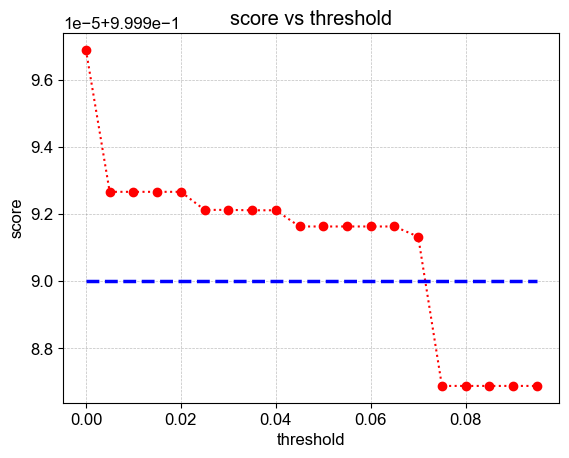

--------------------------------------------------
optimal_threshold: 0.07
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.113 r + -7.345 r_dot + -3.037 q + -0.583 r^2 + -75.116 r^2 r_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999913269795292
Iteration: 1
[ 0.02237461 -0.0368101   0.04466393  0.01342151]


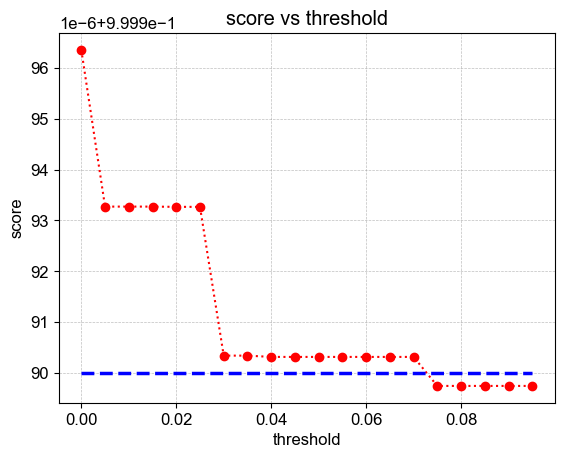

--------------------------------------------------
optimal_threshold: 0.07
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.888 r + -7.335 r_dot + -3.035 q + -0.109 r^2 + 0.904 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 19.684 r + -1.256 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999903175744842
Iteration: 2
[-0.02992729  0.01475361  0.03347414  0.02980579]


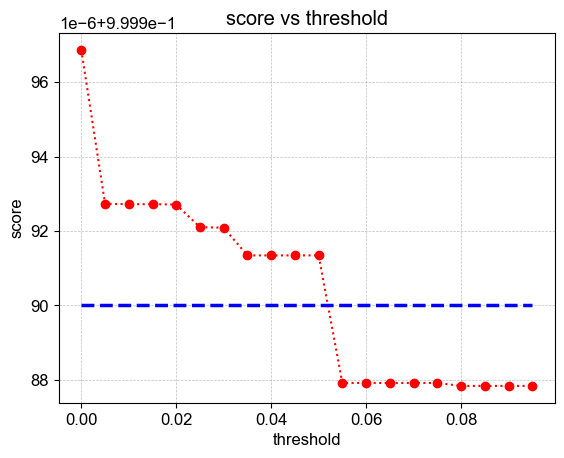

--------------------------------------------------
optimal_threshold: 0.05
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.028 r + -7.349 r_dot + -3.036 q + 0.380 r^2 + -59.034 r^2 r_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999913429103335
Iteration: 3
[-0.00098061 -0.04207242  0.01413899 -0.03590278]


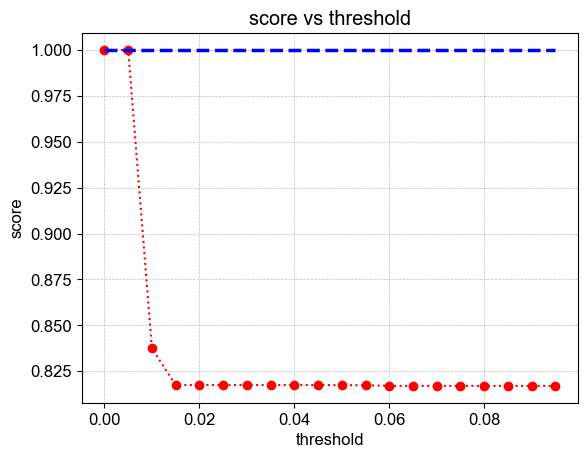

--------------------------------------------------
optimal_threshold: 0.005
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -337.556 r + -7.363 r_dot + -3.032 q + 0.040 r_dot^2 + 0.035 r_dot^2 q + -0.069 r_dot^2 q_dot
(q)' = 0.001 r_dot + 1.000 q_dot
(q_dot)' = 22.819 r + 0.498 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999953650420118
Iteration: 4
[ 0.02328633  0.02209505  0.03949778 -0.04708531]


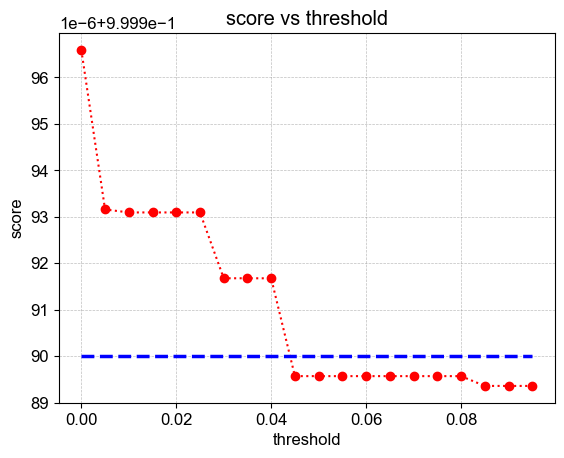

--------------------------------------------------
optimal_threshold: 0.04
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.939 r + -7.348 r_dot + -3.036 q + -0.119 r^2 + -0.013 r_dot^2 + 0.649 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999916753862554
Iteration: 5
[-0.0453876  -0.00938206  0.00466572  0.03330223]


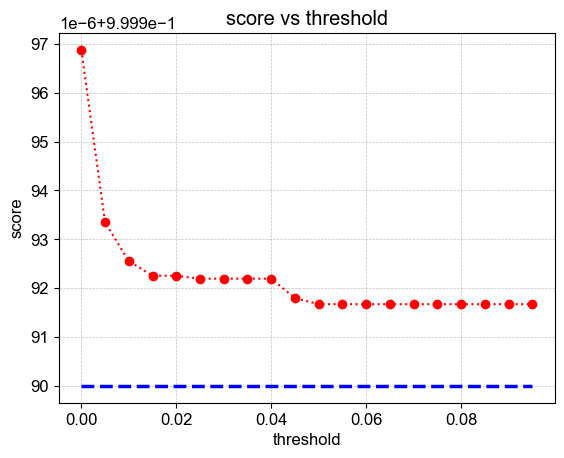

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.135 r + -7.338 r_dot + -3.037 q + 1.340 r^2 + -51.645 r^2 r_dot + 1.341 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999916721320573
Iteration: 6
[-0.00075656  0.04061269 -0.0104954  -0.00028109]


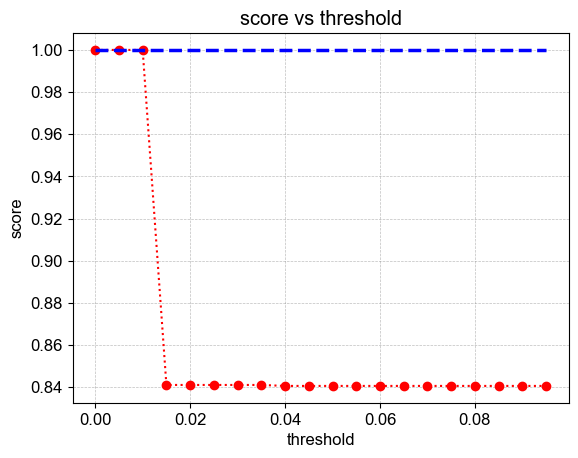

--------------------------------------------------
optimal_threshold: 0.01
--------------------------------------------------
Identified model:
(r)' = 1.000 r_dot
(r_dot)' = -337.224 r + -7.341 r_dot + -3.029 q + -0.011 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 22.792 r + 0.496 r_dot + -1.228 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999984216849371
Iteration: 7
[-0.01735163  0.04602376  0.01158047 -0.00834051]


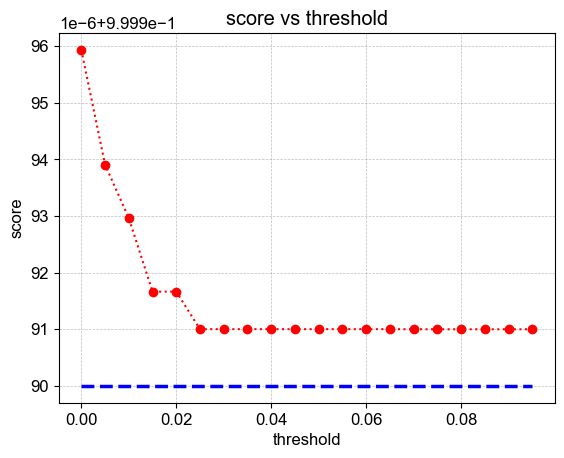

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.849 r + -7.360 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.558 r + -1.257 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999910003075154
Iteration: 8
[0.04497469 0.01397916 0.01235465 0.03997667]


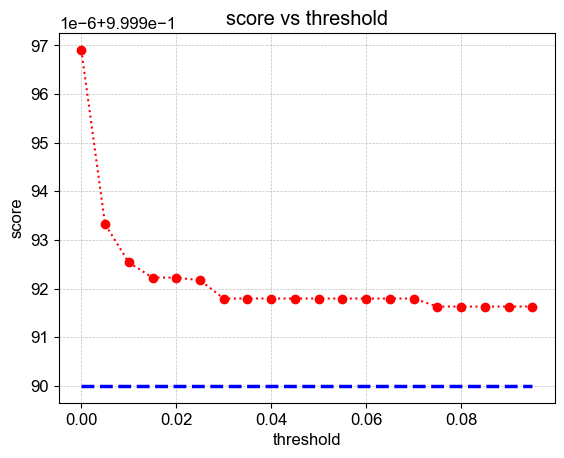

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.147 r + -7.342 r_dot + -3.037 q + -1.282 r^2 + -52.908 r^2 r_dot + -0.839 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999916310253332
Iteration: 9
[ 0.01664684 -0.03694871 -0.00145293 -0.02245328]


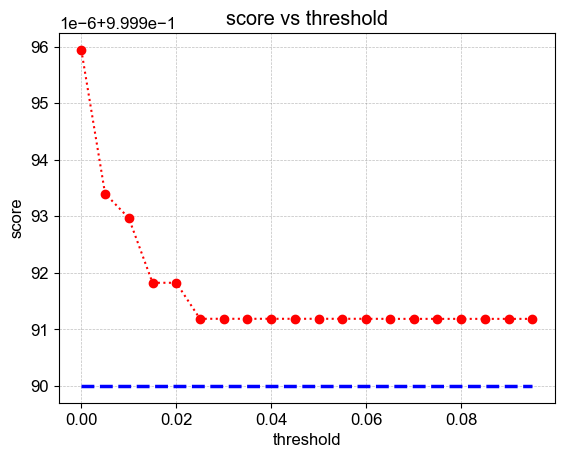

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.863 r + -7.362 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.608 r + -1.256 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999911856081193
Iteration: 10
[ 0.03549133 -0.04343626  0.03828135  0.0425293 ]


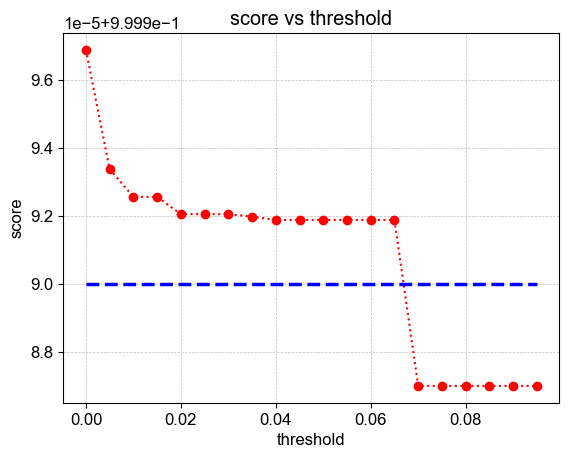

--------------------------------------------------
optimal_threshold: 0.065
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.108 r + -7.320 r_dot + -3.037 q + -0.557 r^2 + -67.470 r^2 r_dot + -1.511 r_dot^2 q + 1.323 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.842 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999918796542074
Iteration: 11
[0.00481787 0.04761806 0.0259306  0.04767117]


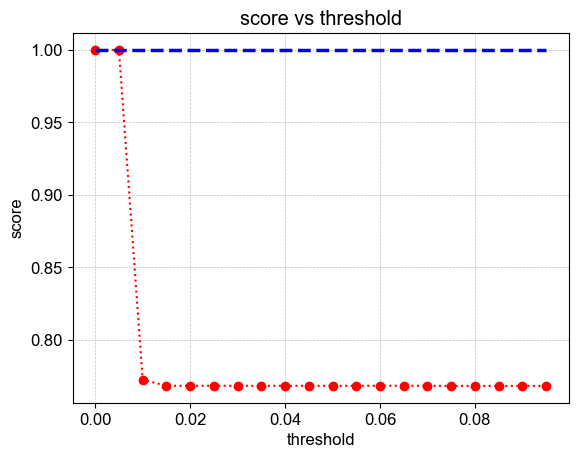

--------------------------------------------------
optimal_threshold: 0.005
--------------------------------------------------
Identified model:
(r)' = 1.000 r_dot
(r_dot)' = -337.923 r + -7.359 r_dot + -3.035 q + -0.156 r_dot^2 + -0.057 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.498 r_dot + -1.227 q + 0.287 q_dot + 0.010 r_dot^2 + -0.287 q^2 q_dot
Score on training data:
0.9999933482361553
Iteration: 12
[0.00754783 0.04192009 0.01287095 0.03541393]


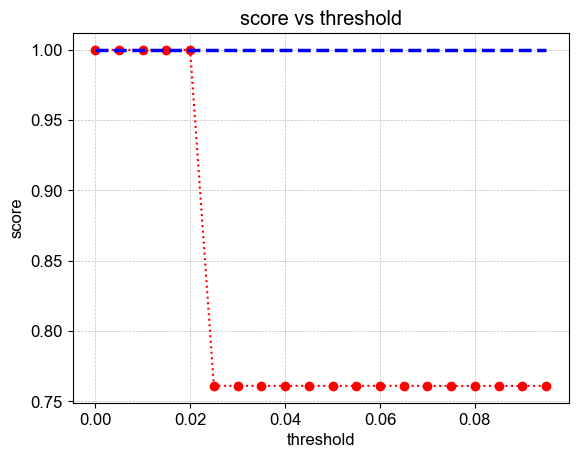

--------------------------------------------------
optimal_threshold: 0.02
--------------------------------------------------
Identified model:
(r)' = 1.000 r_dot
(r_dot)' = -337.937 r + -7.376 r_dot + -3.036 q + -0.254 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 22.847 r + 0.497 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999930166457635
Iteration: 13
[-0.02974954 -0.02686008 -0.02972724  0.03467821]


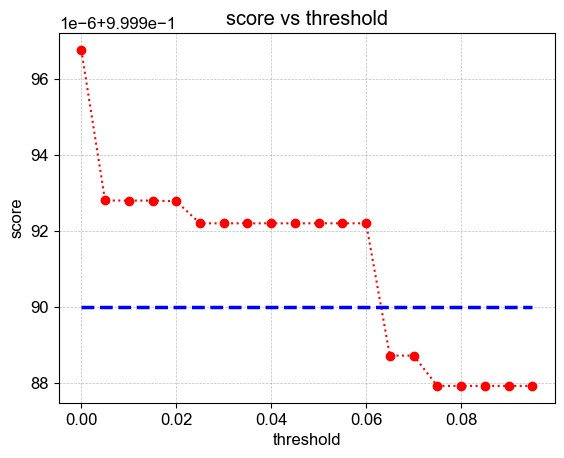

--------------------------------------------------
optimal_threshold: 0.06
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.324 r + -7.320 r_dot + -3.039 q + 0.371 r^2 + 0.013 r_dot^2 + -209.361 r^2 r_dot + 1.246 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999922039866469
Iteration: 14
[ 0.00395928 -0.02900259 -0.04726031 -0.03303078]


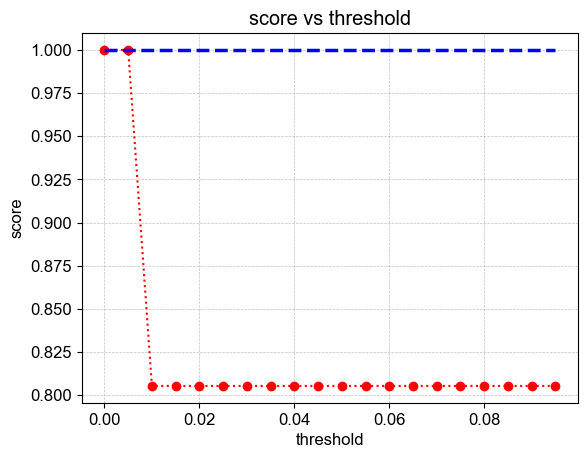

--------------------------------------------------
optimal_threshold: 0.005
--------------------------------------------------
Identified model:
(r)' = 0.995 r_dot
(r_dot)' = -337.599 r + -7.368 r_dot + -3.032 q + 0.046 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.825 r + 0.495 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999967466436523
Iteration: 15
[ 0.02055849  0.01770705 -0.04783502 -0.00329484]


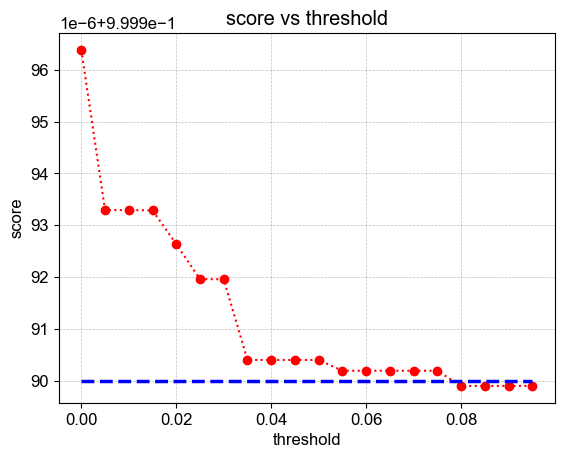

--------------------------------------------------
optimal_threshold: 0.075
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.931 r + -7.368 r_dot + -3.035 q + -0.045 r^2 + -0.107 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 20.012 r + -1.253 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999901923250735
Iteration: 16
[-0.00848962  0.02819194  0.00234266 -0.02676356]


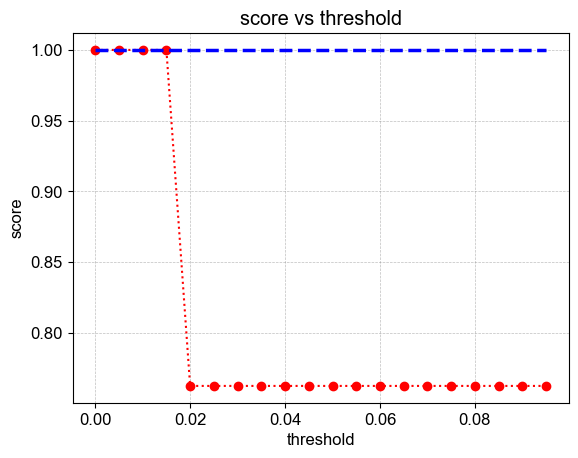

--------------------------------------------------
optimal_threshold: 0.015
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.828 r + -7.370 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.488 r + -1.257 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999936424885947
Iteration: 17
[-0.02749187 -0.03291269  0.02467375  0.01869451]


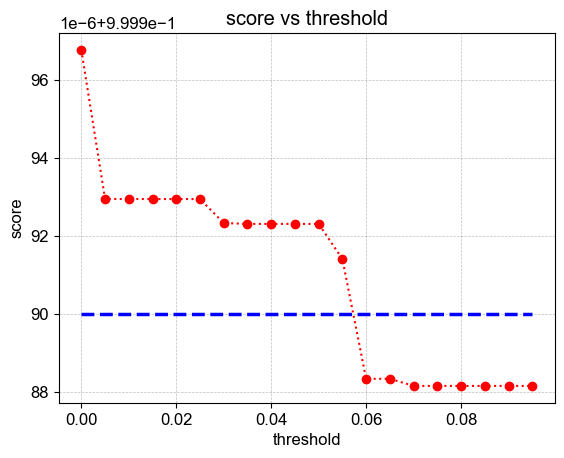

--------------------------------------------------
optimal_threshold: 0.055
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -337.937 r + -7.347 r_dot + -3.036 q + 0.206 r^2 + 0.033 r_dot^2 + 0.670 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999914060859489
Iteration: 18
[0.04187812 0.02460184 0.04201931 0.02252554]


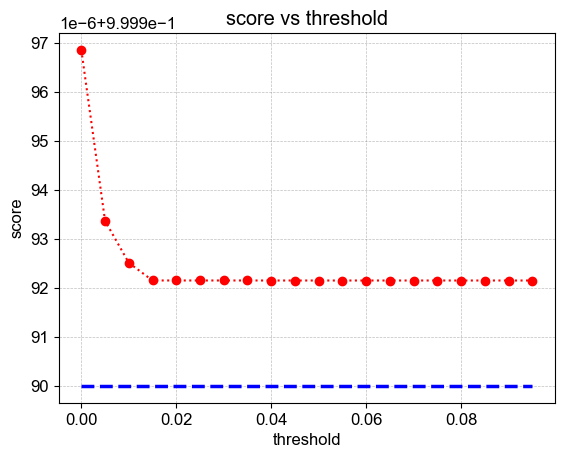

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.330 r + -7.314 r_dot + -3.039 q + -0.987 r^2 + -0.072 r_dot^2 + -107.035 r^2 r_dot + -0.380 r_dot^2 q + 1.519 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999921510581713
Iteration: 19
[ 0.04822867 -0.0295951   0.04022378 -0.0246879 ]


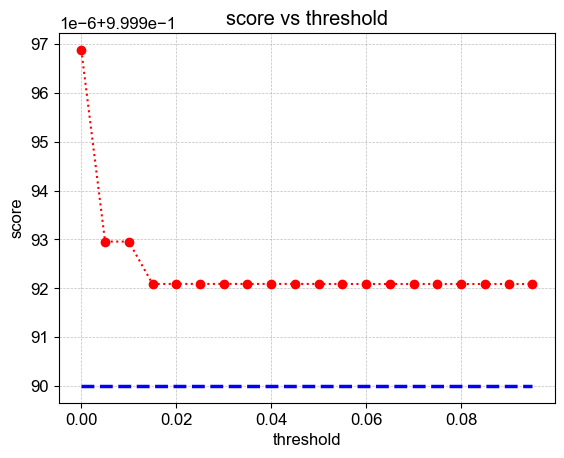

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.218 r + -7.313 r_dot + -3.038 q + -1.353 r^2 + -59.336 r^2 r_dot + -0.154 r_dot^2 q + 1.482 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999920879038573
Iteration: 20
[ 0.04930105 -0.03916846  0.04939642 -0.03355514]


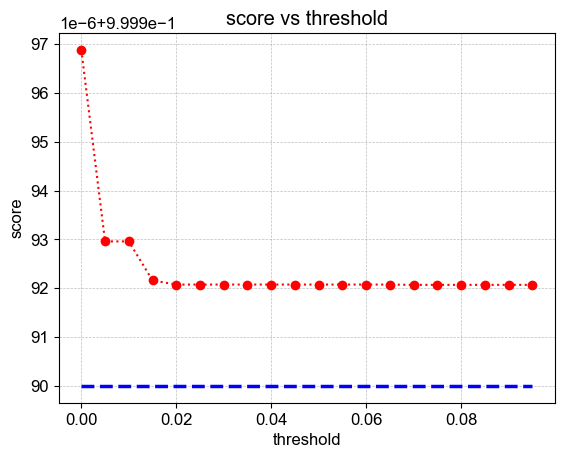

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.191 r + -7.314 r_dot + -3.038 q + -1.384 r^2 + -52.155 r^2 r_dot + 0.170 r_dot^2 q + 1.383 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.842 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + 0.074 r^2 + -0.287 q^2 q_dot
Score on training data:
0.9999920688898711
Iteration: 21
[ 0.00462429 -0.01551916  0.00878249  0.04531533]


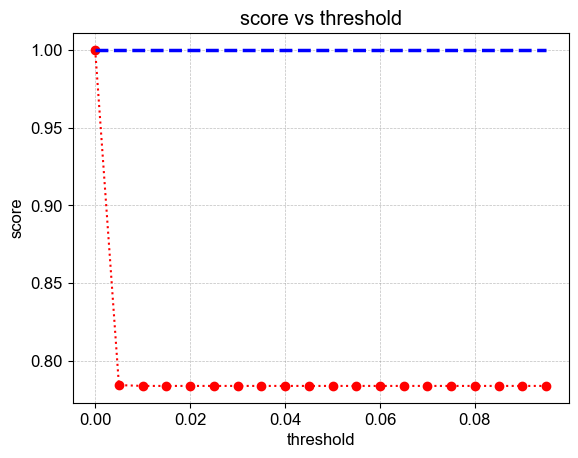

--------------------------------------------------
optimal_threshold: 0.0
--------------------------------------------------
Identified model:
(r)' = 0.015 r + 0.995 r_dot + -0.052 r^2 + 0.005 r_dot^2 + 12.826 r^2 r_dot + 0.004 r^2 q + -0.723 r^2 q_dot + -0.036 r_dot^2 q
(r_dot)' = -337.817 r + -7.326 r_dot + -3.034 q + -0.995 r^2 + 0.088 r_dot^2 + 244.717 r^2 r_dot + 0.077 r^2 q + -13.823 r^2 q_dot + -0.682 r_dot^2 q + 0.001 r_dot^2 q_dot + 0.001 q^2 q_dot
(q)' = -0.007 r + 0.001 r_dot + 1.000 q_dot + -0.008 r^2 + -0.001 r_dot^2 + -104.977 r^2 r_dot + 0.055 r^2 q + -0.790 r^2 q_dot + -0.115 r_dot^2 q
(q_dot)' = 22.845 r + 0.495 r_dot + -1.227 q + 0.287 q_dot + -0.002 r^2 + -0.046 r_dot^2 + 154.245 r^2 r_dot + -0.032 r^2 q + 77.463 r^2 q_dot + 3.352 r_dot^2 q + -0.155 r_dot^2 q_dot + -0.293 q^2 q_dot
Score on training data:
0.9999966301365699
Iteration: 22
[ 0.04817621 -0.01546913  0.04751371  0.01859901]


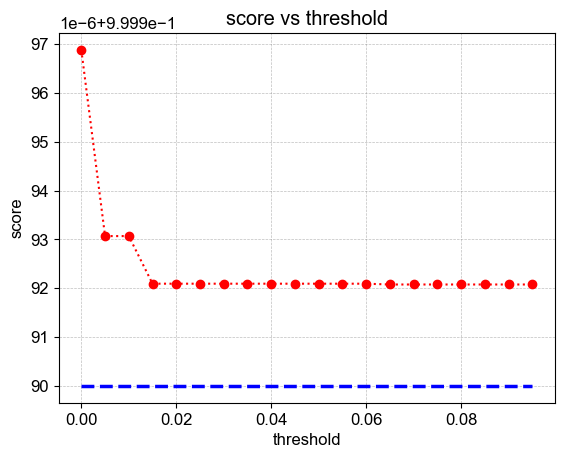

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.242 r + -7.311 r_dot + -3.038 q + -1.391 r^2 + -62.202 r^2 r_dot + -1.342 r_dot^2 q + 1.561 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + 0.073 r^2 + -0.287 q^2 q_dot
Score on training data:
0.9999920774188147
Iteration: 23
[ 0.04787201 -0.03005616  0.0016104   0.02174469]


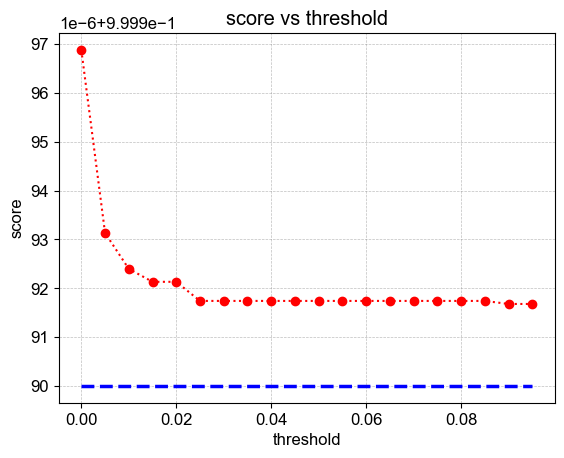

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.040 r + -7.338 r_dot + -3.036 q + -1.518 r^2 + -29.601 r^2 r_dot + -0.009 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999916790833845
Iteration: 24
[ 0.00527477  0.02412321 -0.03735308 -0.01648747]


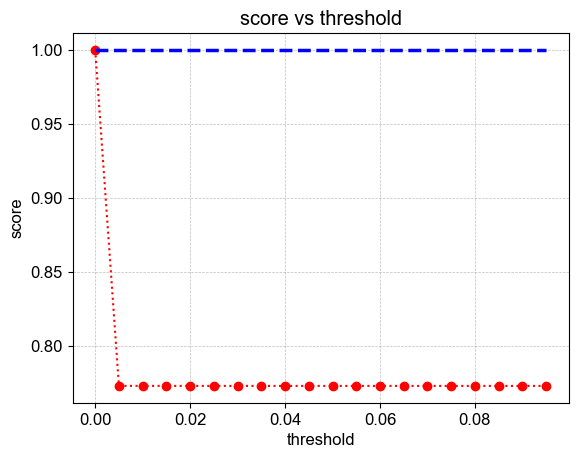

--------------------------------------------------
optimal_threshold: 0.0
--------------------------------------------------
Identified model:
(r)' = 0.027 r + 0.995 r_dot + -0.047 r^2 + -0.011 r_dot^2 + -118.133 r^2 r_dot + -0.027 r^2 q + -2.322 r^2 q_dot + -0.055 r_dot^2 q + 0.001 r_dot^2 q_dot
(r_dot)' = -338.277 r + -7.333 r_dot + -3.039 q + -3.099 r^2 + -0.738 r_dot^2 + -7807.444 r^2 r_dot + -1.769 r^2 q + -153.463 r^2 q_dot + -3.615 r_dot^2 q + 0.058 r_dot^2 q_dot + 0.007 q^2 q_dot
(q)' = -0.003 r + 1.000 q_dot + -0.007 r^2 + -0.003 r_dot^2 + -30.740 r^2 r_dot + 0.072 r^2 q + 0.809 r^2 q_dot + -0.075 r_dot^2 q + -0.001 r_dot^2 q_dot
(q_dot)' = 22.873 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + 0.431 r^2 + 0.177 r_dot^2 + 583.459 r^2 r_dot + 0.066 r^2 q + 84.857 r^2 q_dot + 3.507 r_dot^2 q + -0.159 r_dot^2 q_dot + -0.294 q^2 q_dot
Score on training data:
0.9999959101852589
Iteration: 25
[-0.0386267   0.03731406  0.0374549   0.04751948]


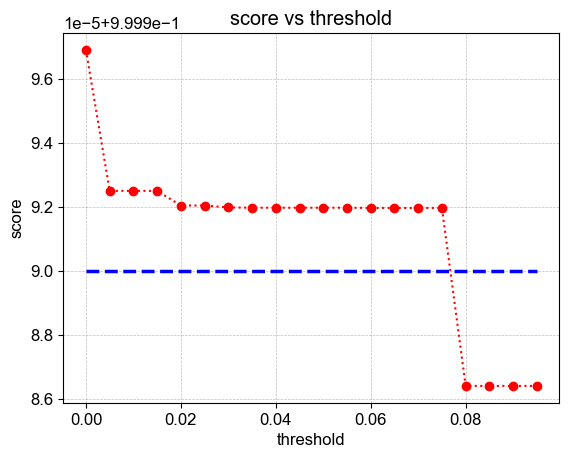

--------------------------------------------------
optimal_threshold: 0.075
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.172 r + -7.325 r_dot + -3.038 q + 0.693 r^2 + -79.319 r^2 r_dot + 1.194 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999919703340558
Iteration: 26
[ 0.00227134  0.01108599  0.02452854 -0.04668136]


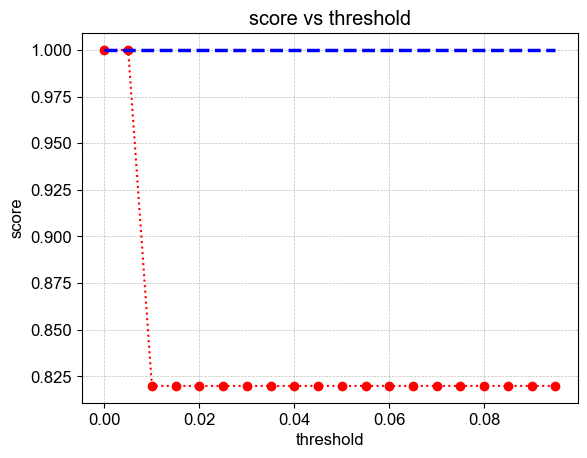

--------------------------------------------------
optimal_threshold: 0.005
--------------------------------------------------
Identified model:
(r)' = 0.995 r_dot
(r_dot)' = -337.969 r + -7.377 r_dot + -3.036 q + 0.010 r_dot^2 q + 0.010 r_dot^2 q_dot
(q)' = 0.001 r_dot + 1.000 q_dot
(q_dot)' = 22.846 r + 0.497 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.999995110400803
Iteration: 27
[-0.01797543 -0.0232931  -0.03922539 -0.01003805]


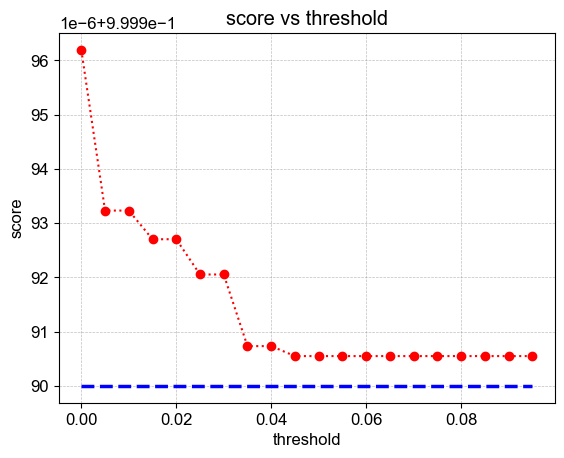

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.936 r + -7.370 r_dot + -3.036 q + 0.003 r^2 + 0.122 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 20.067 r + -1.252 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999905498928259
Iteration: 28
[-0.03841462  0.04199036  0.00996762  0.01989382]


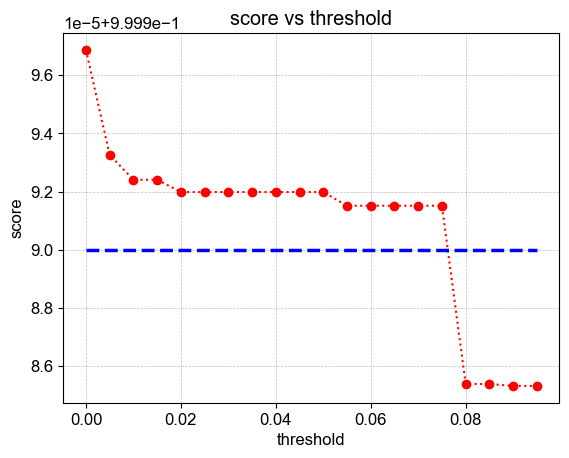

--------------------------------------------------
optimal_threshold: 0.075
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -337.988 r + -7.344 r_dot + -3.036 q + 0.749 r^2 + -29.542 r^2 r_dot + 1.140 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999915115809945
Iteration: 29
[-0.0314043  -0.01140965 -0.01896316  0.04682947]


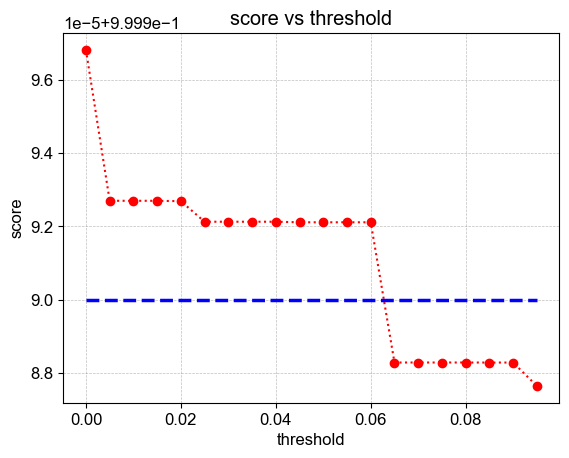

--------------------------------------------------
optimal_threshold: 0.06
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.298 r + -7.321 r_dot + -3.039 q + 0.435 r^2 + -0.007 r_dot^2 + -172.623 r^2 r_dot + 1.263 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999921146708091
Iteration: 30
[ 0.00396818 -0.03023058 -0.0193512   0.01988366]


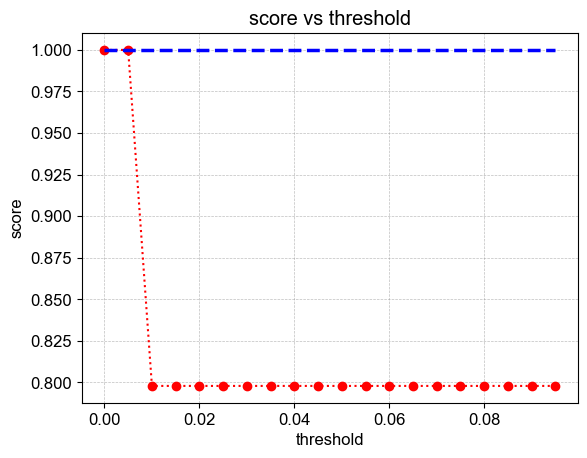

--------------------------------------------------
optimal_threshold: 0.005
--------------------------------------------------
Identified model:
(r)' = 0.995 r_dot
(r_dot)' = -337.615 r + -7.369 r_dot + -3.033 q + 0.046 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.826 r + 0.495 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999965267130129
Iteration: 31
[ 0.00097047  0.02782059 -0.02577463 -0.00330653]


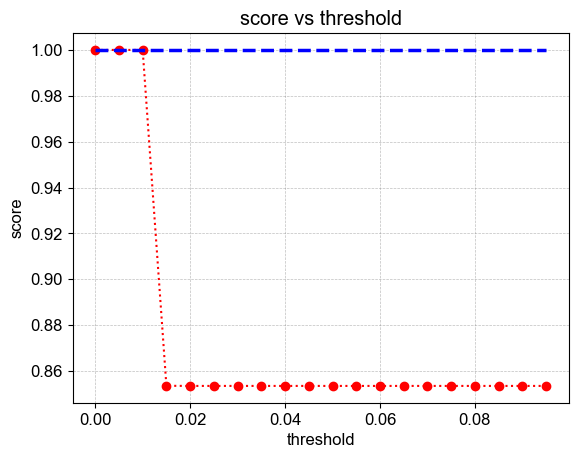

--------------------------------------------------
optimal_threshold: 0.01
--------------------------------------------------
Identified model:
(r)' = 1.000 r_dot
(r_dot)' = -337.643 r + -7.370 r_dot + -3.033 q + -0.013 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 22.823 r + 0.498 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999961092809166
Iteration: 32
[ 0.02858775 -0.0473243  -0.0047594  -0.01784285]


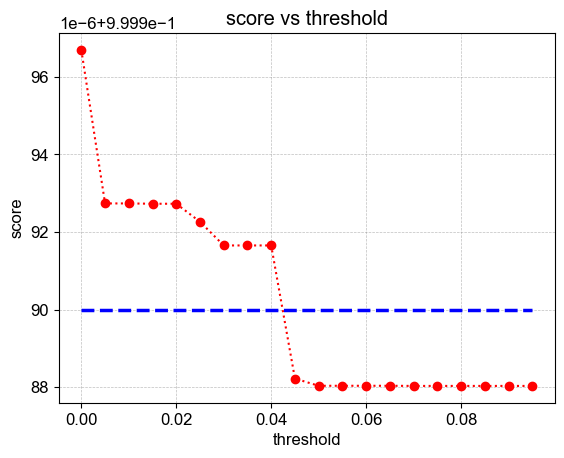

--------------------------------------------------
optimal_threshold: 0.04
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -337.968 r + -7.356 r_dot + -3.036 q + -0.269 r^2 + -0.064 r_dot^2 + -44.448 r^2 r_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.842 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999916553205623
Iteration: 33
[-0.0068516   0.02772617 -0.03528813  0.00759793]


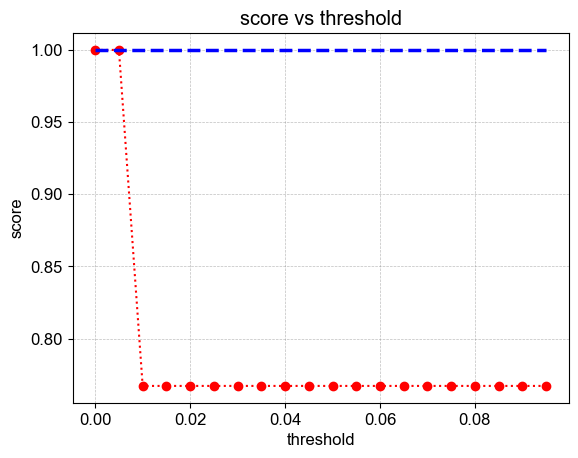

--------------------------------------------------
optimal_threshold: 0.005
--------------------------------------------------
Identified model:
(r)' = 1.000 r_dot
(r_dot)' = -337.828 r + -7.359 r_dot + -3.035 q + -0.080 r_dot^2 q + 0.368 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 19.429 r + -1.258 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999946327831482
Iteration: 34
[ 0.02456326 -0.04907195  0.01056268  0.00653729]


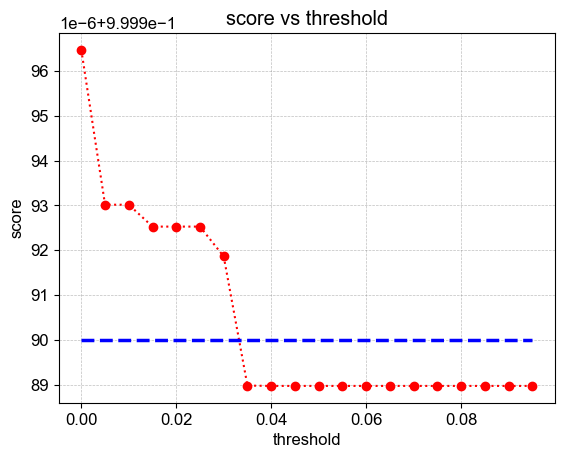

--------------------------------------------------
optimal_threshold: 0.03
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -337.936 r + -7.357 r_dot + -3.036 q + -0.151 r^2 + -0.079 r_dot^2 + -44.701 r^2 r_dot + 0.363 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.841 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999918606089084
Iteration: 35
[ 0.00977251 -0.04857717 -0.00409824 -0.01077621]


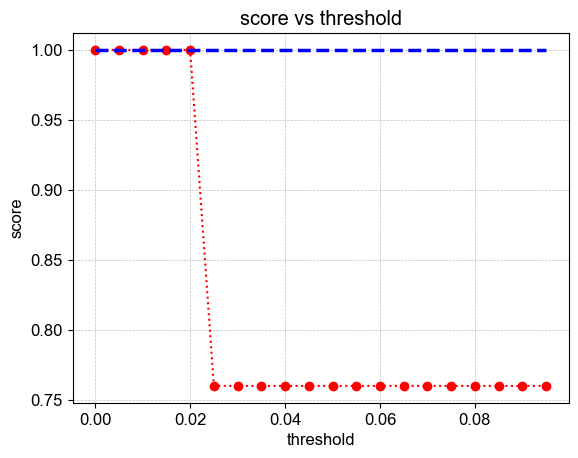

--------------------------------------------------
optimal_threshold: 0.02
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.757 r + -7.366 r_dot + -3.034 q
(q)' = 1.000 q_dot
(q_dot)' = 19.328 r + -1.259 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999936073081217
Iteration: 36
[-0.01454966  0.003647    0.00852447 -0.00116655]


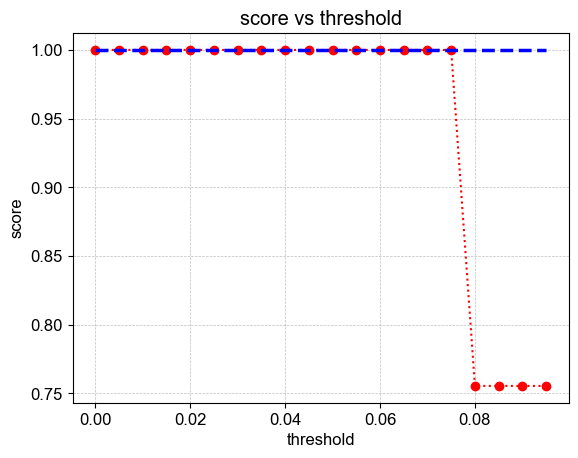

--------------------------------------------------
optimal_threshold: 0.075
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.913 r + -7.366 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.859 r + -1.254 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.999991159422368
Iteration: 37
[ 0.0142712   0.00485617 -0.00131053 -0.00360535]


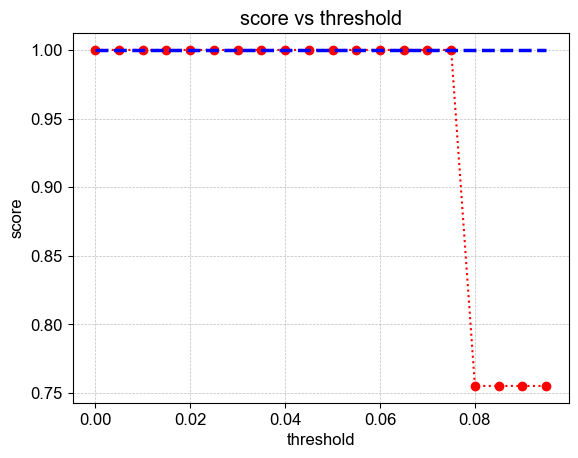

--------------------------------------------------
optimal_threshold: 0.075
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.924 r + -7.365 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.938 r + -1.253 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999908092902581
Iteration: 38
[ 0.0298306  -0.02339659  0.03835626 -0.0296621 ]


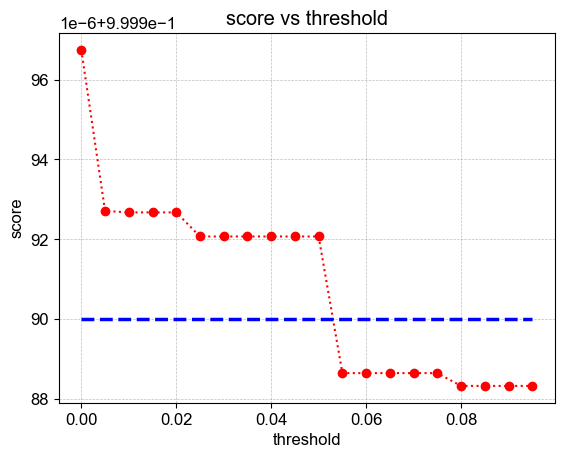

--------------------------------------------------
optimal_threshold: 0.05
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.184 r + -7.324 r_dot + -3.038 q + -0.342 r^2 + -133.148 r^2 r_dot + 1.183 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999920716508197
Iteration: 39
[ 0.00229128  0.00067487  0.04723544 -0.01266471]


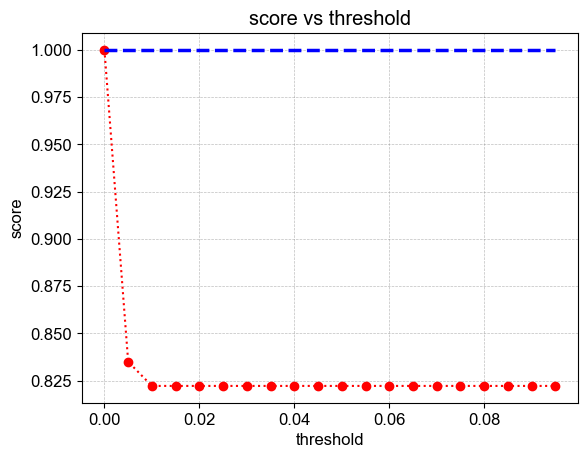

--------------------------------------------------
optimal_threshold: 0.0
--------------------------------------------------
Identified model:
(r)' = 0.022 r + 0.995 r_dot + -0.008 r^2 + -24.727 r^2 r_dot + -0.005 r^2 q + -0.463 r^2 q_dot + -0.010 r_dot^2 q
(r_dot)' = -337.930 r + -7.335 r_dot + -3.035 q + -0.242 r^2 + -0.008 r_dot^2 + -761.610 r^2 r_dot + -0.169 r^2 q + -14.258 r^2 q_dot + -0.316 r_dot^2 q + 0.005 r_dot^2 q_dot + 0.001 q^2 q_dot
(q)' = -0.004 r + 0.001 r_dot + 1.000 q_dot + 0.014 r^2 + 0.010 r_dot^2 + -277.653 r^2 r_dot + 0.016 r^2 q + -4.228 r^2 q_dot + -0.197 r_dot^2 q + 0.001 r_dot^2 q_dot
(q_dot)' = 22.847 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.245 r^2 + -0.153 r_dot^2 + 378.097 r^2 r_dot + 0.019 r^2 q + 80.854 r^2 q_dot + 3.412 r_dot^2 q + -0.157 r_dot^2 q_dot + -0.293 q^2 q_dot
Score on training data:
0.9999964191810293
Iteration: 40
[-0.00610255  0.02266036 -0.01657811  0.02062277]


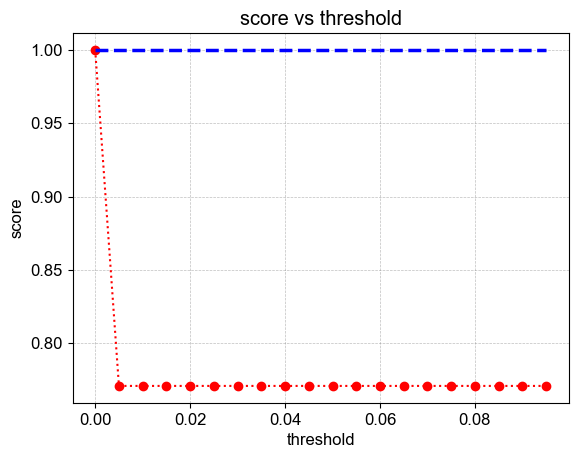

--------------------------------------------------
optimal_threshold: 0.0
--------------------------------------------------
Identified model:
(r)' = 0.018 r + 0.995 r_dot + 0.128 r^2 + -0.003 r_dot^2 + 39.825 r^2 r_dot + 0.008 r^2 q + 1.985 r^2 q_dot + 0.070 r_dot^2 q
(r_dot)' = -337.742 r + -7.327 r_dot + -3.034 q + 2.298 r^2 + -0.059 r_dot^2 + 717.464 r^2 r_dot + 0.137 r^2 q + 35.751 r^2 q_dot + 1.264 r_dot^2 q + -0.005 r_dot^2 q_dot + -0.002 q^2 q_dot
(q)' = -0.004 r + 1.000 q_dot + 0.004 r^2 + -28.132 r^2 r_dot + 0.072 r^2 q + 0.812 r^2 q_dot + -0.076 r_dot^2 q + -0.001 r_dot^2 q_dot
(q_dot)' = 22.833 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.110 r^2 + 0.051 r_dot^2 + -49.362 r^2 r_dot + -0.075 r^2 q + 70.539 r^2 q_dot + 3.132 r_dot^2 q + -0.154 r_dot^2 q_dot + -0.293 q^2 q_dot
Score on training data:
0.999996523176331
Iteration: 41
[ 0.03706246  0.02353383 -0.02384772  0.02732983]


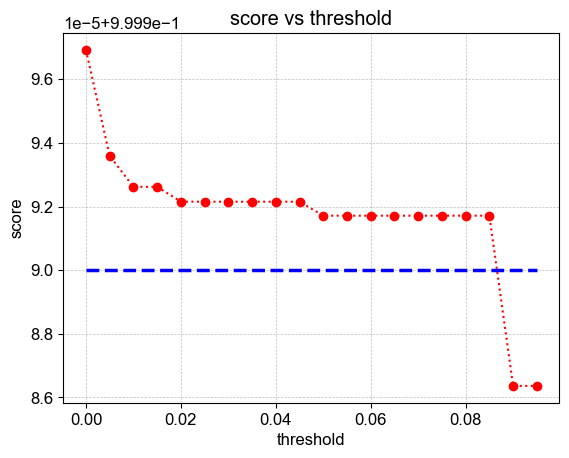

--------------------------------------------------
optimal_threshold: 0.085
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.225 r + -7.350 r_dot + -3.038 q + -0.698 r^2 + -0.055 r_dot^2 + -104.173 r^2 r_dot + 0.644 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999917127238395
Iteration: 42
[ 0.01433205 -0.04079262 -0.00896694 -0.02013108]


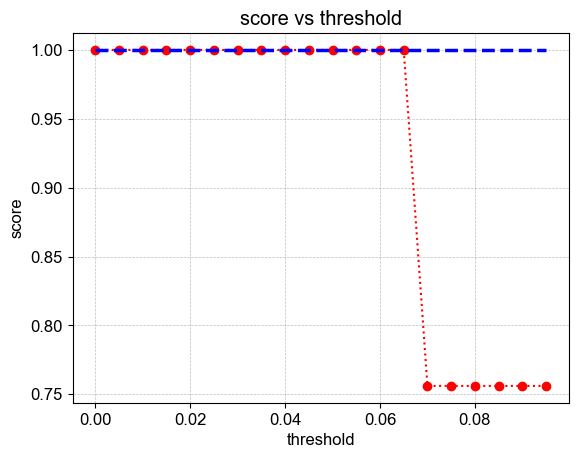

--------------------------------------------------
optimal_threshold: 0.065
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.842 r + -7.364 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.534 r + -1.257 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999919475501275
Iteration: 43
[ 0.03764128 -0.00723249 -0.03044005 -0.03014608]


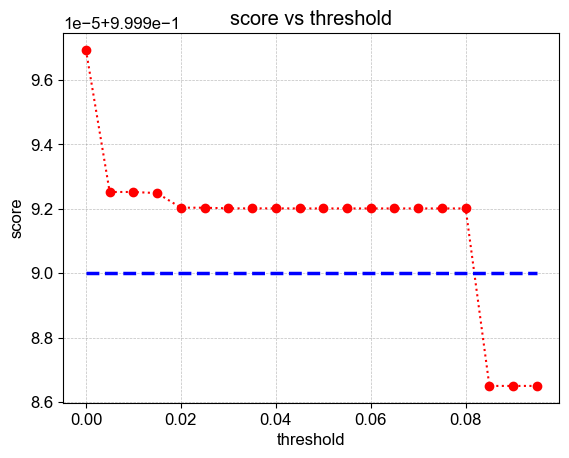

--------------------------------------------------
optimal_threshold: 0.08
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.248 r + -7.316 r_dot + -3.038 q + -0.730 r^2 + -106.022 r^2 r_dot + 1.451 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999920099082333
Iteration: 44
[ 0.04166117  0.04203606  0.01430776 -0.0407512 ]


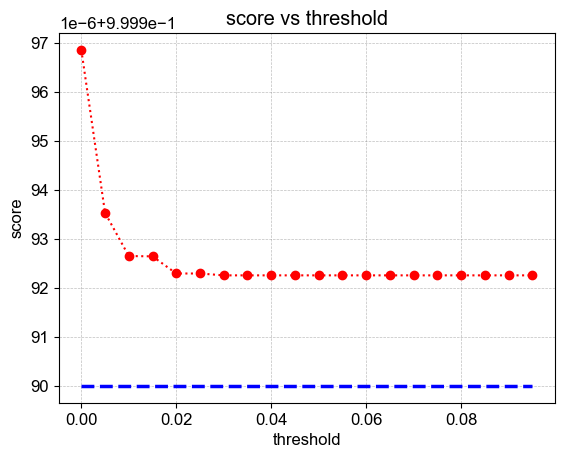

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.358 r + -7.315 r_dot + -3.039 q + -1.021 r^2 + -0.006 r_dot^2 + -119.373 r^2 r_dot + 1.500 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999922540039945
Iteration: 45
[-0.03964226  0.00992366  0.02138291  0.02132926]


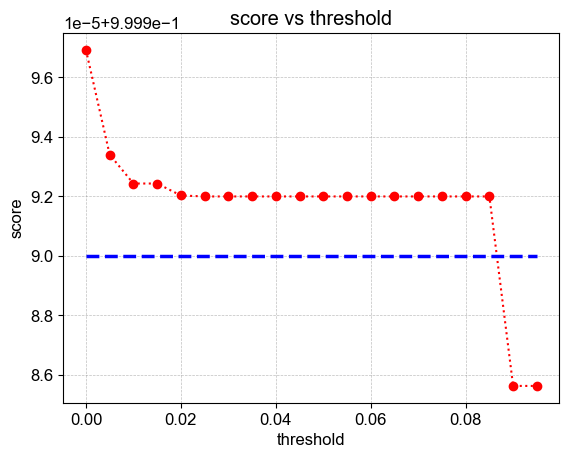

--------------------------------------------------
optimal_threshold: 0.085
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.232 r + -7.314 r_dot + -3.038 q + 0.879 r^2 + -92.039 r^2 r_dot + 0.354 r_dot^2 q + 1.440 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999919969238042
Iteration: 46
[ 0.00634673 -0.03072344 -0.03230112 -0.00999027]


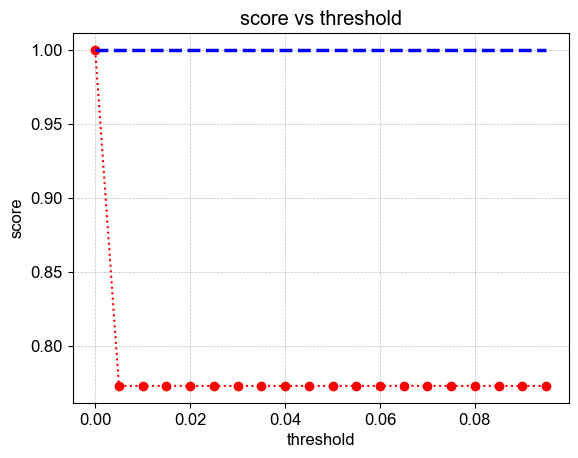

--------------------------------------------------
optimal_threshold: 0.0
--------------------------------------------------
Identified model:
(r)' = 0.023 r + 0.995 r_dot + -0.093 r^2 + 0.010 r_dot^2 + 98.651 r^2 r_dot + 0.021 r^2 q + 2.383 r^2 q_dot + 0.065 r_dot^2 q + -0.001 r_dot^2 q_dot
(r_dot)' = -337.587 r + -7.326 r_dot + -3.032 q + -1.370 r^2 + 0.147 r_dot^2 + 1460.156 r^2 r_dot + 0.316 r^2 q + 35.267 r^2 q_dot + 0.957 r_dot^2 q + -0.011 r_dot^2 q_dot + -0.002 q^2 q_dot
(q)' = -0.004 r + 1.000 q_dot + -0.010 r^2 + -0.004 r_dot^2 + -28.122 r^2 r_dot + 0.072 r^2 q + 0.868 r^2 q_dot + -0.073 r_dot^2 q + -0.001 r_dot^2 q_dot
(q_dot)' = 22.825 r + 0.495 r_dot + -1.227 q + 0.287 q_dot + 0.286 r^2 + 0.097 r_dot^2 + -80.857 r^2 r_dot + -0.084 r^2 q + 71.333 r^2 q_dot + 3.179 r_dot^2 q + -0.154 r_dot^2 q_dot + -0.293 q^2 q_dot
Score on training data:
0.9999971647166118
Iteration: 47
[ 0.04526963  0.0490479  -0.0398883   0.04066874]


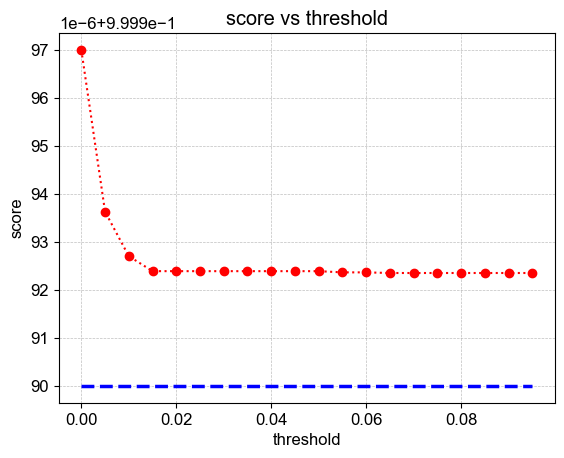

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.370 r + -7.314 r_dot + -3.039 q + -1.154 r^2 + -0.160 r_dot^2 + -107.134 r^2 r_dot + -0.178 r_dot^2 q + 1.581 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + 0.059 r^2 + -0.287 q^2 q_dot
Score on training data:
0.9999923513942827
Iteration: 48
[ 0.00653394 -0.02929221 -0.04043031  0.01088144]


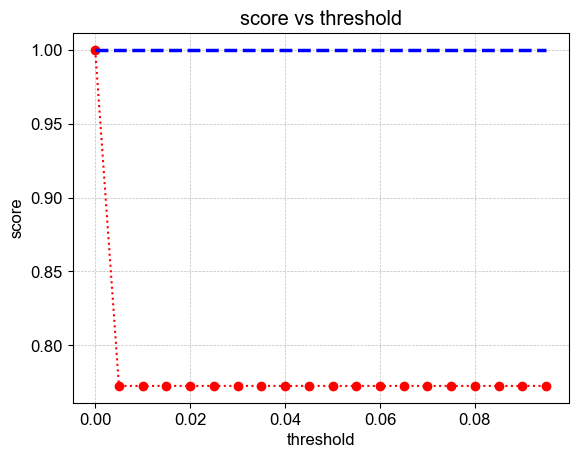

--------------------------------------------------
optimal_threshold: 0.0
--------------------------------------------------
Identified model:
(r)' = 0.022 r + 0.995 r_dot + -0.106 r^2 + 0.007 r_dot^2 + 75.503 r^2 r_dot + 0.017 r^2 q + 0.911 r^2 q_dot + 0.010 r_dot^2 q + -0.001 r_dot^2 q_dot
(r_dot)' = -337.626 r + -7.326 r_dot + -3.033 q + -1.648 r^2 + 0.115 r_dot^2 + 1172.986 r^2 r_dot + 0.267 r^2 q + 14.154 r^2 q_dot + 0.160 r_dot^2 q + -0.008 r_dot^2 q_dot
(q)' = -0.004 r + 1.000 q_dot + -0.006 r^2 + -0.004 r_dot^2 + -24.592 r^2 r_dot + 0.073 r^2 q + 0.942 r^2 q_dot + -0.072 r_dot^2 q + -0.001 r_dot^2 q_dot
(q_dot)' = 22.828 r + 0.495 r_dot + -1.227 q + 0.287 q_dot + 0.335 r^2 + 0.120 r_dot^2 + -38.853 r^2 r_dot + -0.074 r^2 q + 73.044 r^2 q_dot + 3.236 r_dot^2 q + -0.154 r_dot^2 q_dot + -0.293 q^2 q_dot
Score on training data:
0.9999970012759486
Iteration: 49
[-0.00121998 -0.01506511 -0.02289919 -0.0341438 ]


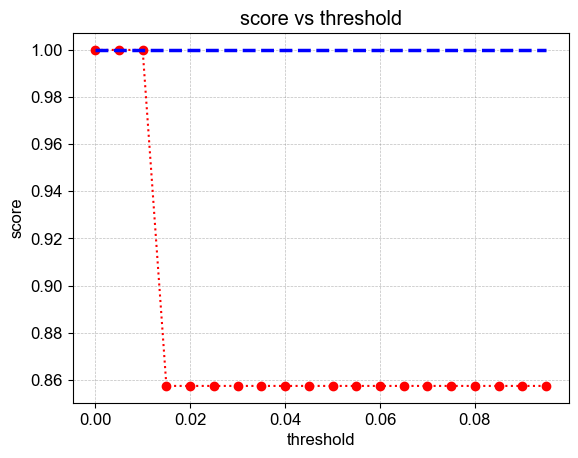

--------------------------------------------------
optimal_threshold: 0.01
--------------------------------------------------
Identified model:
(r)' = 1.000 r_dot
(r_dot)' = -337.928 r + -7.377 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.497 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999959587318404
Iteration: 50
[-0.04750063 -0.03466046 -0.0328904   0.00751882]


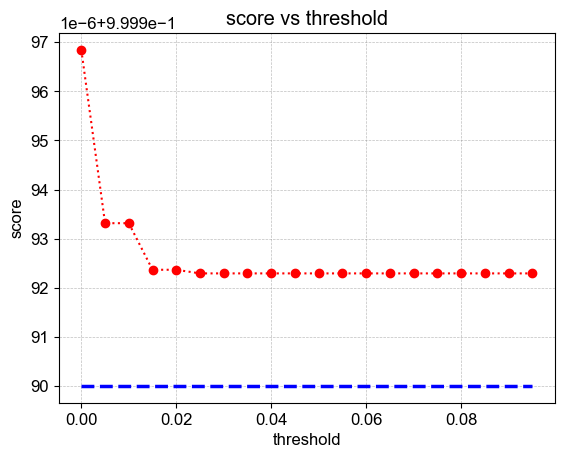

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.344 r + -7.310 r_dot + -3.039 q + 1.444 r^2 + 0.034 r_dot^2 + -88.615 r^2 r_dot + -0.482 r_dot^2 q + 1.618 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.072 r^2 + -0.287 q^2 q_dot
Score on training data:
0.9999922917941412
Iteration: 51
[-0.02324868 -0.00900346 -0.04690622 -0.04626321]


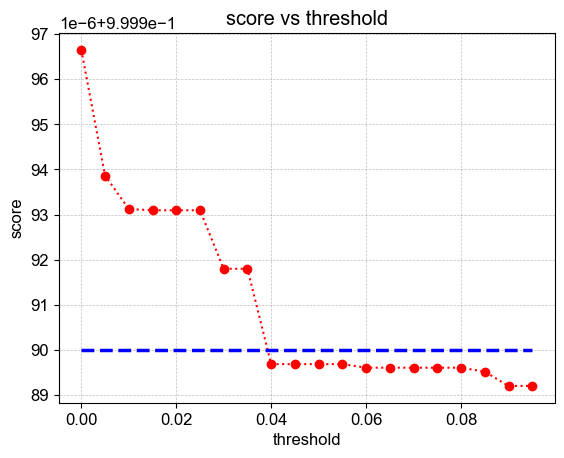

--------------------------------------------------
optimal_threshold: 0.035
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.931 r + -7.346 r_dot + -3.035 q + 0.099 r^2 + 0.064 r_dot^2 + -0.126 r_dot^2 q + 0.701 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999917989066205
Iteration: 52
[ 0.0121772  -0.00373038 -0.00389579 -0.03376937]


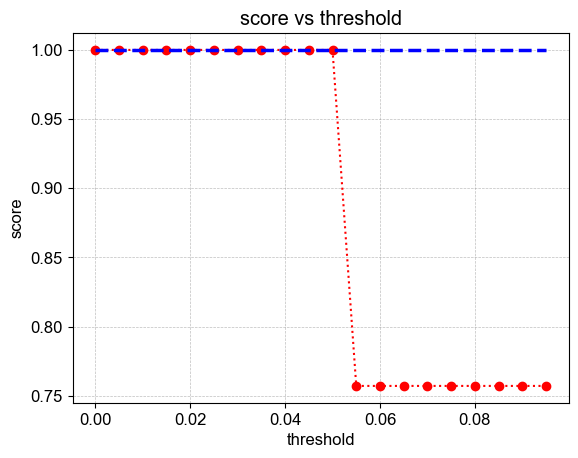

--------------------------------------------------
optimal_threshold: 0.05
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.912 r + -7.369 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.848 r + -1.254 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999920451029763
Iteration: 53
[-0.00863629 -0.00667179 -0.01915014  0.00745242]


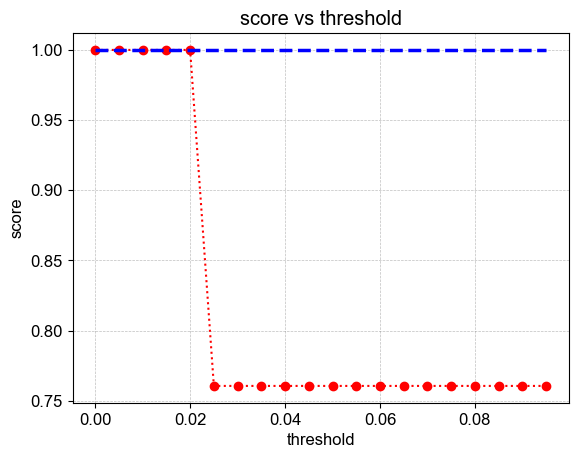

--------------------------------------------------
optimal_threshold: 0.02
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.930 r + -7.373 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.994 r + -1.253 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999927102312662
Iteration: 54
[-0.02474053  0.01318151 -0.0108789   0.04185359]


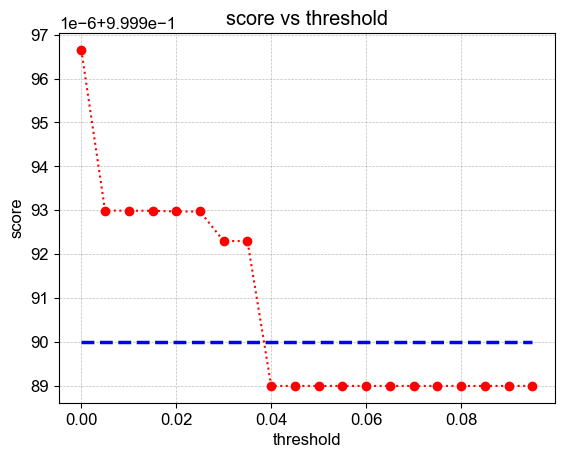

--------------------------------------------------
optimal_threshold: 0.035
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.174 r + -7.326 r_dot + -3.038 q + 0.197 r^2 + -186.285 r^2 r_dot + 1.052 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999922992531971
Iteration: 55
[-0.04338317 -0.03810368  0.04141577 -0.00681056]


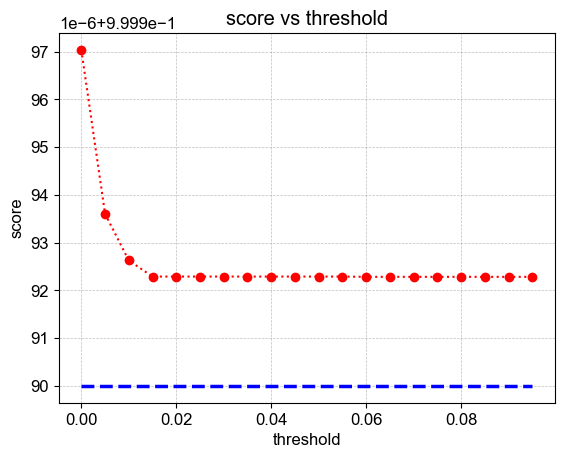

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.359 r + -7.315 r_dot + -3.039 q + 1.073 r^2 + 0.109 r_dot^2 + -111.756 r^2 r_dot + -0.361 r_dot^2 q + 1.558 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999922849343135
Iteration: 56
[ 0.03619055  0.04598329 -0.04015774 -0.04881817]


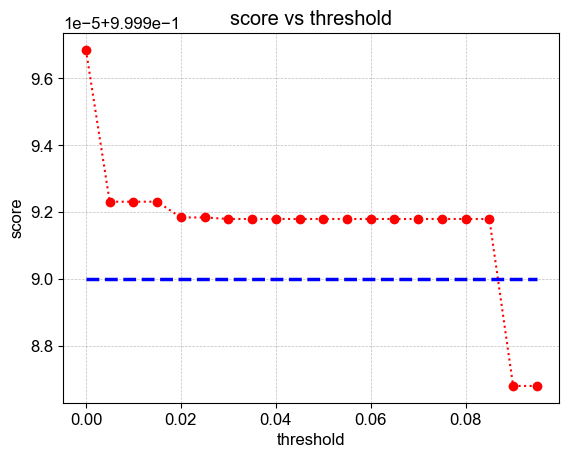

--------------------------------------------------
optimal_threshold: 0.085
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.268 r + -7.352 r_dot + -3.038 q + -0.628 r^2 + -0.080 r_dot^2 + -126.281 r^2 r_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999917977253568
Iteration: 57
[ 0.03817949 -0.0307839   0.03454048  0.0496566 ]


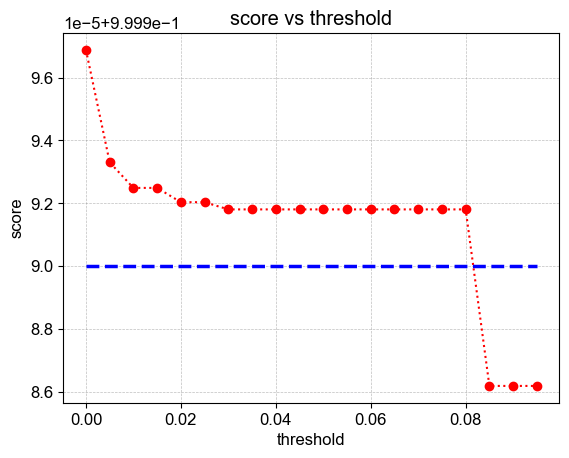

--------------------------------------------------
optimal_threshold: 0.08
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.141 r + -7.320 r_dot + -3.037 q + -0.712 r^2 + -65.909 r^2 r_dot + -1.873 r_dot^2 q + 1.261 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999918076168858
Iteration: 58
[-0.03710542  0.0488399   0.04397848  0.02904977]


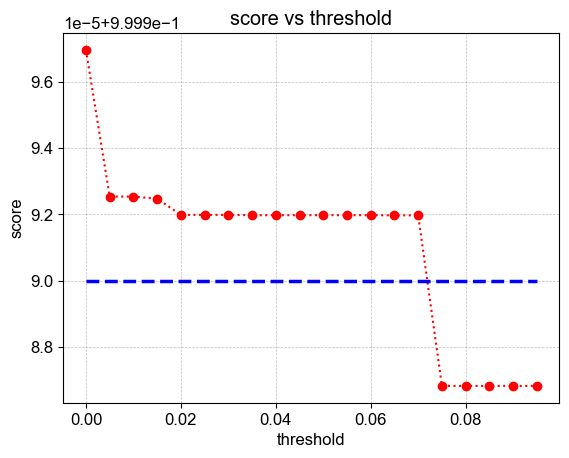

--------------------------------------------------
optimal_threshold: 0.07
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.113 r + -7.321 r_dot + -3.037 q + 0.607 r^2 + -69.576 r^2 r_dot + 1.289 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.842 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999919743904321
Iteration: 59
[ 0.01292024 -0.00332308 -0.03386008  0.01144014]


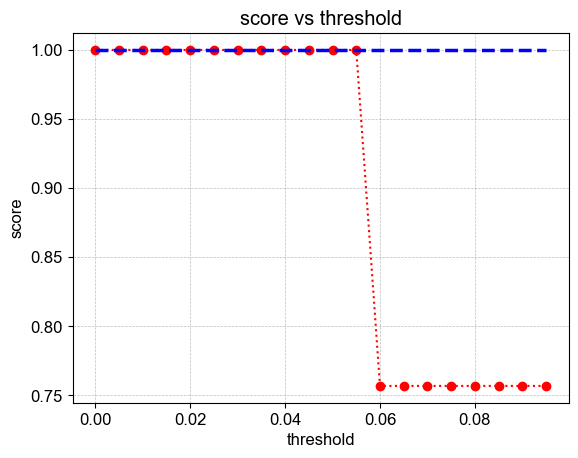

--------------------------------------------------
optimal_threshold: 0.055
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.913 r + -7.369 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.858 r + -1.254 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999919527732981
Iteration: 60
[ 0.02835555 -0.01767752 -0.03744579 -0.02651593]


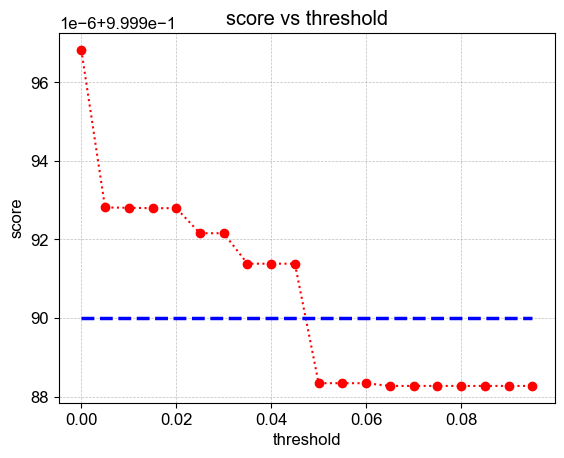

--------------------------------------------------
optimal_threshold: 0.045
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.015 r + -7.350 r_dot + -3.036 q + -0.323 r^2 + -59.832 r^2 r_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999913830864857
Iteration: 61
[-0.01483421 -0.04781456  0.00202643  0.02059114]


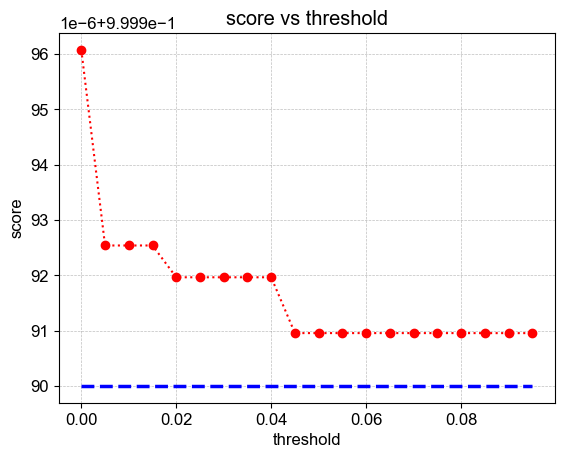

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.946 r + -7.373 r_dot + -3.036 q + 0.168 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 20.335 r + -1.250 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999909549796224
Iteration: 62
[-0.04987611  0.04280736  0.04534705  0.03696703]


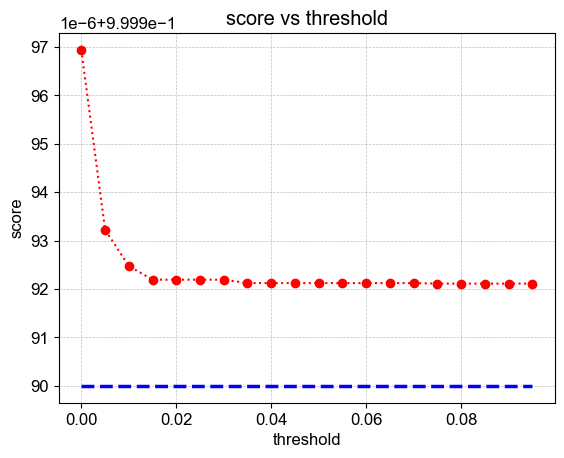

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.190 r + -7.312 r_dot + -3.038 q + 1.458 r^2 + -54.423 r^2 r_dot + 0.031 r_dot^2 q + 1.543 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.842 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.076 r^2 + -0.287 q^2 q_dot
Score on training data:
0.9999921127807352
Iteration: 63
[-0.02219525  0.03517117 -0.04779327  0.01314029]


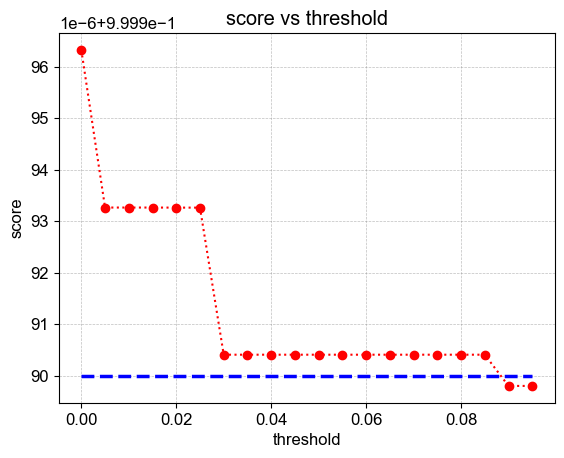

--------------------------------------------------
optimal_threshold: 0.085
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.890 r + -7.339 r_dot + -3.035 q + 0.103 r^2 + 0.847 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 19.690 r + -1.256 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999904097489963
Iteration: 64
[ 0.00146309  0.03991534  0.03428496 -0.00044344]


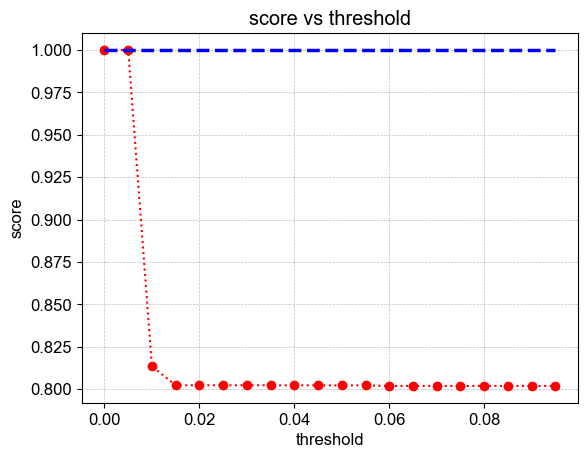

--------------------------------------------------
optimal_threshold: 0.005
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -337.768 r + -7.363 r_dot + -3.034 q + -0.051 r_dot^2 + 0.025 r_dot^2 q + -0.056 r_dot^2 q_dot
(q)' = 0.001 r_dot + 1.000 q_dot
(q_dot)' = 22.833 r + 0.498 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999944490343632
Iteration: 65
[ 0.0205028   0.02736743 -0.01126785 -0.03062361]


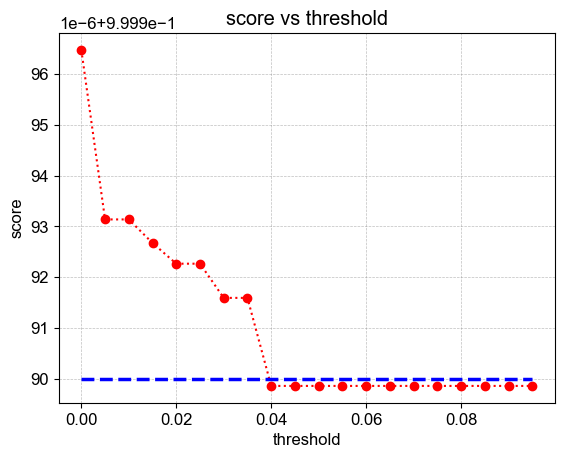

--------------------------------------------------
optimal_threshold: 0.035
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.937 r + -7.368 r_dot + -3.036 q + -0.048 r^2 + -0.106 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999915943335518
Iteration: 66
[ 0.01571305 -0.02337296  0.01719976 -0.00397888]


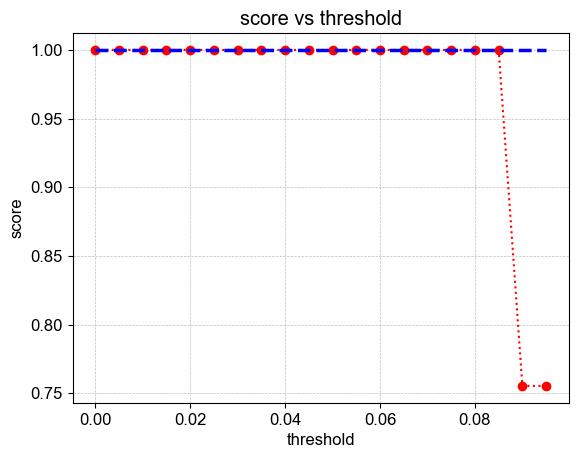

--------------------------------------------------
optimal_threshold: 0.085
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.885 r + -7.364 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.701 r + -1.256 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999912262921375
Iteration: 67
[ 0.0213808   0.01072199 -0.04124443 -0.02142425]


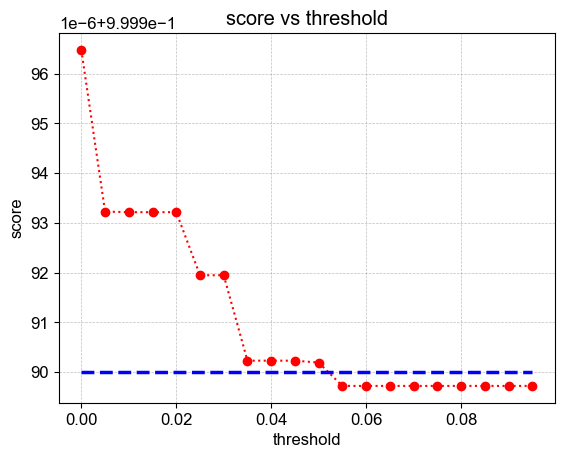

--------------------------------------------------
optimal_threshold: 0.05
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.930 r + -7.344 r_dot + -3.035 q + -0.110 r^2 + 0.752 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 19.960 r + -1.253 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999901941452862
Iteration: 68
[ 0.03068133  0.0188996  -0.01409776  0.04884526]


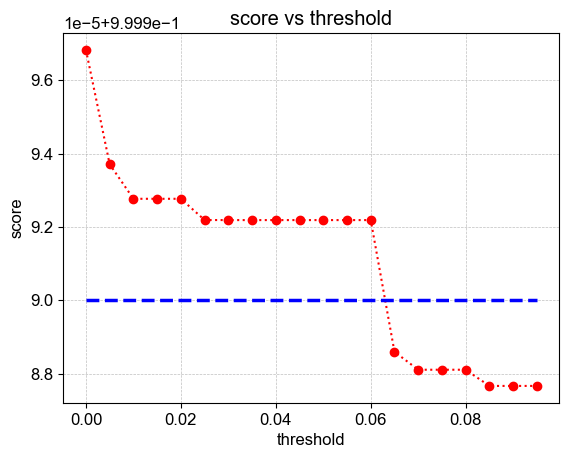

--------------------------------------------------
optimal_threshold: 0.06
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.322 r + -7.321 r_dot + -3.039 q + -0.341 r^2 + -0.133 r_dot^2 + -193.174 r^2 r_dot + -0.472 r_dot^2 q + 1.291 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999921863220824
Iteration: 69
[-0.0378882   0.04460723  0.00529615  0.04103627]


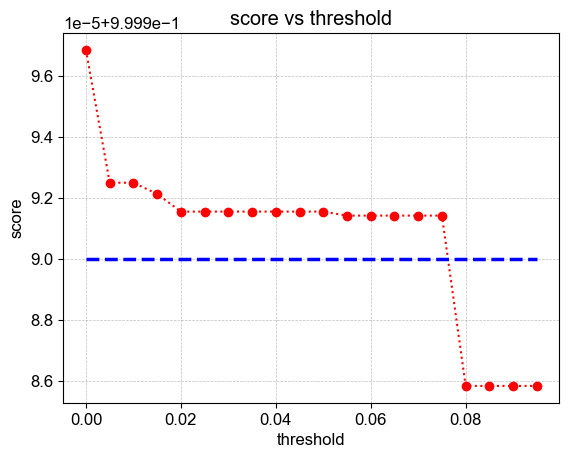

--------------------------------------------------
optimal_threshold: 0.075
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -337.951 r + -7.345 r_dot + -3.036 q + 0.673 r^2 + -19.171 r^2 r_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.842 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999914229566587
Iteration: 70
[-0.03027131  0.01911678  0.00742011  0.04047274]


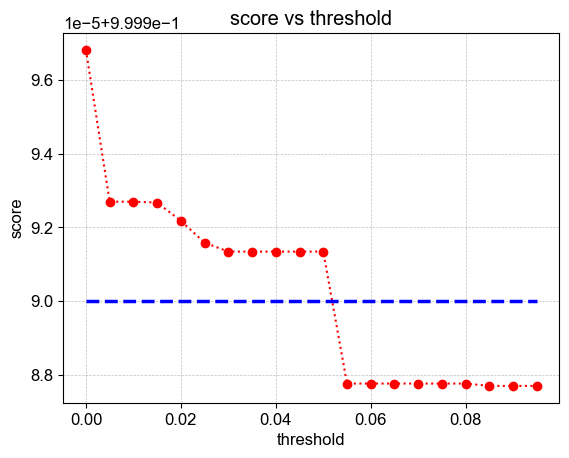

--------------------------------------------------
optimal_threshold: 0.05
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.014 r + -7.349 r_dot + -3.036 q + 0.387 r^2 + -52.440 r^2 r_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999913403017604
Iteration: 71
[ 0.03007284 -0.00720695  0.02863065  0.0132198 ]


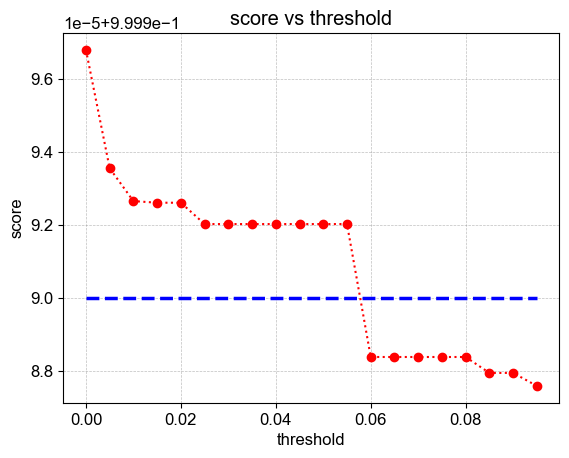

--------------------------------------------------
optimal_threshold: 0.055
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.236 r + -7.316 r_dot + -3.038 q + -0.394 r^2 + -153.845 r^2 r_dot + -1.083 r_dot^2 q + 1.416 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999920258233692
Iteration: 72
[0.02249162 0.00887914 0.03788672 0.03682945]


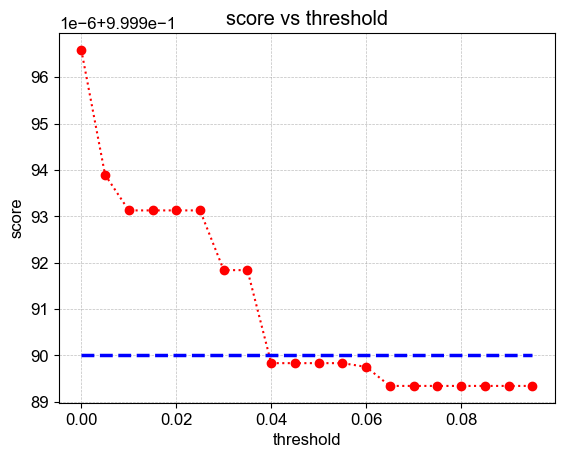

--------------------------------------------------
optimal_threshold: 0.035
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.931 r + -7.347 r_dot + -3.035 q + -0.090 r^2 + -0.062 r_dot^2 + -0.118 r_dot^2 q + 0.687 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999918398866178
Iteration: 73
[-0.03390359  0.00224151  0.00792971  0.01773101]


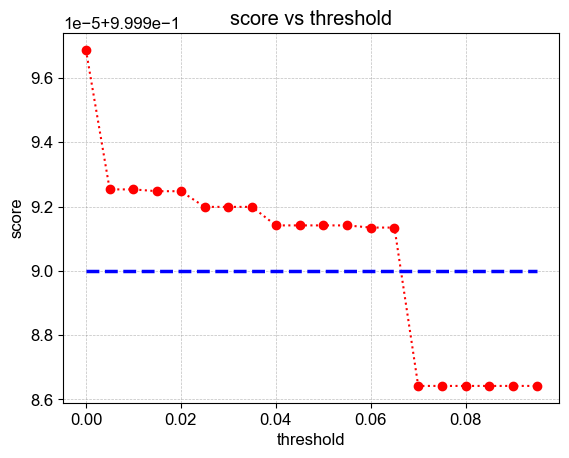

--------------------------------------------------
optimal_threshold: 0.065
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.080 r + -7.344 r_dot + -3.037 q + 0.616 r^2 + -65.239 r^2 r_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.999991345675649
Iteration: 74
[-0.02528999 -0.04614104 -0.04791926  0.03418883]


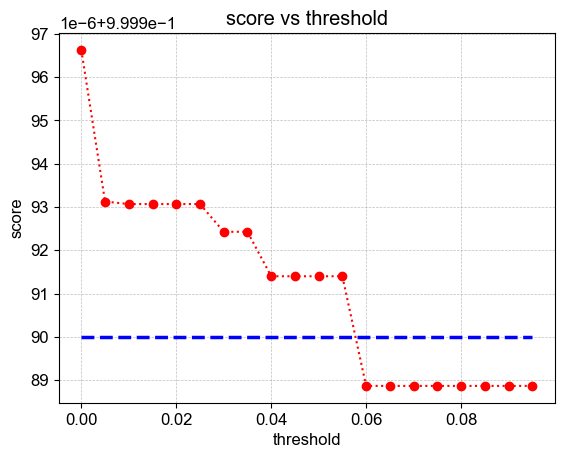

--------------------------------------------------
optimal_threshold: 0.055
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -337.949 r + -7.350 r_dot + -3.036 q + 0.147 r^2 + 0.026 r_dot^2 + 0.609 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.999991400153855
Iteration: 75
[ 3.22939496e-02  1.42314315e-03  8.75041132e-05 -3.73319429e-03]


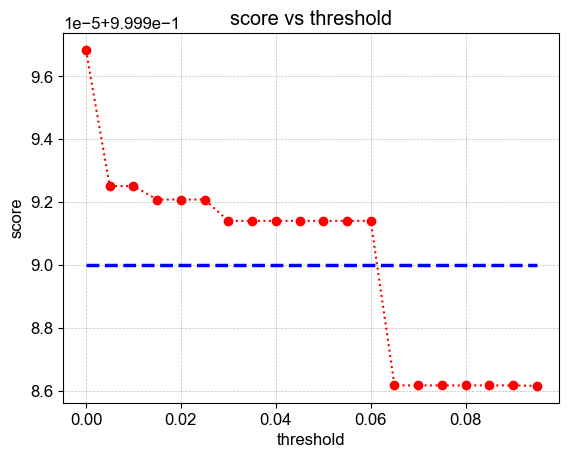

--------------------------------------------------
optimal_threshold: 0.06
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.102 r + -7.342 r_dot + -3.037 q + -0.619 r^2 + -81.759 r^2 r_dot + 0.612 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999913988233998
Iteration: 76
[0.02832561 0.02159349 0.01072053 0.0400145 ]


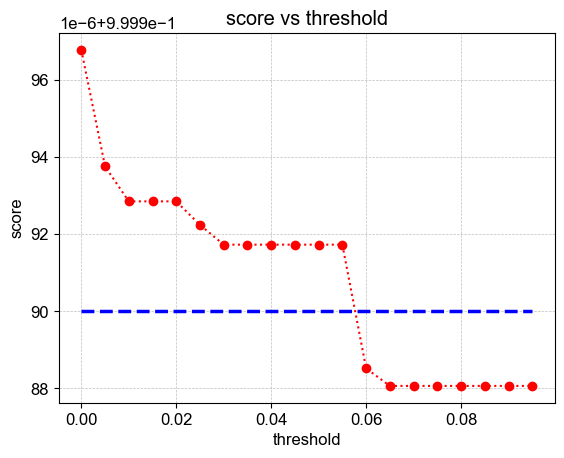

--------------------------------------------------
optimal_threshold: 0.055
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.198 r + -7.354 r_dot + -3.038 q + -0.283 r^2 + -0.096 r_dot^2 + -161.011 r^2 r_dot + 0.324 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999917261691416
Iteration: 77
[ 0.03364108 -0.02761418  0.02868068 -0.03239951]


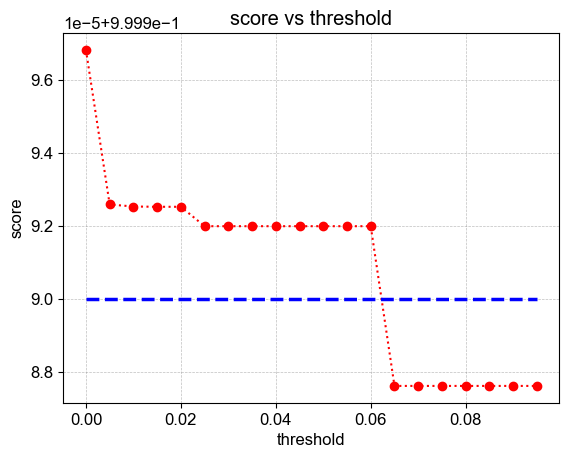

--------------------------------------------------
optimal_threshold: 0.06
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.185 r + -7.323 r_dot + -3.038 q + -0.488 r^2 + -105.626 r^2 r_dot + 1.223 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999919885349184
Iteration: 78
[ 0.01618175 -0.02431904 -0.04842208  0.04169937]


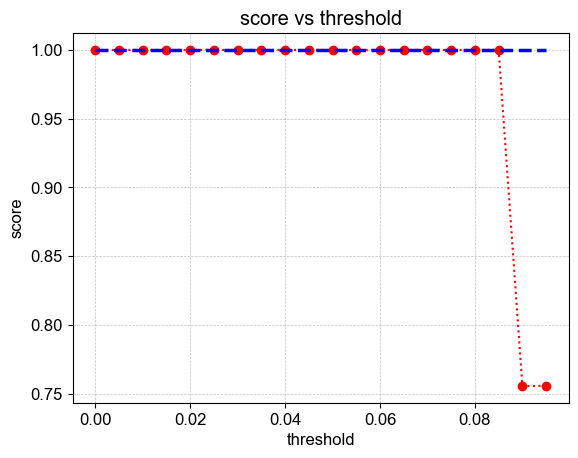

--------------------------------------------------
optimal_threshold: 0.085
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.884 r + -7.365 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.695 r + -1.256 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.999991497747721
Iteration: 79
[ 0.02096348  0.02680719 -0.01481516  0.0284269 ]


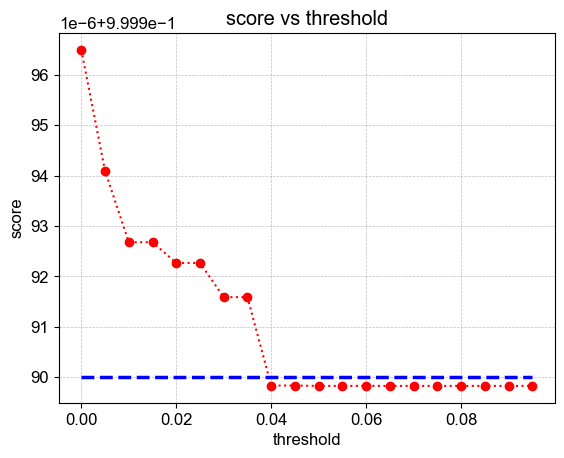

--------------------------------------------------
optimal_threshold: 0.035
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.936 r + -7.368 r_dot + -3.036 q + -0.056 r^2 + -0.099 r_dot^2 + 0.244 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999915882145289
Iteration: 80
[ 0.00565579  0.04288808  0.03920483 -0.04709723]


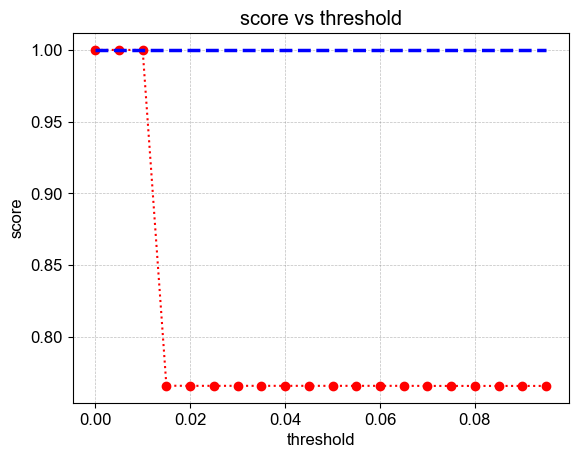

--------------------------------------------------
optimal_threshold: 0.01
--------------------------------------------------
Identified model:
(r)' = 1.000 r_dot
(r_dot)' = -337.925 r + -7.376 r_dot + -3.035 q + -0.226 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.497 r_dot + -1.227 q + 0.287 q_dot + 0.009 r_dot^2 + -0.287 q^2 q_dot
Score on training data:
0.9999931787495893
Iteration: 81
[-0.02876765  0.04399504 -0.02963438 -0.0410717 ]


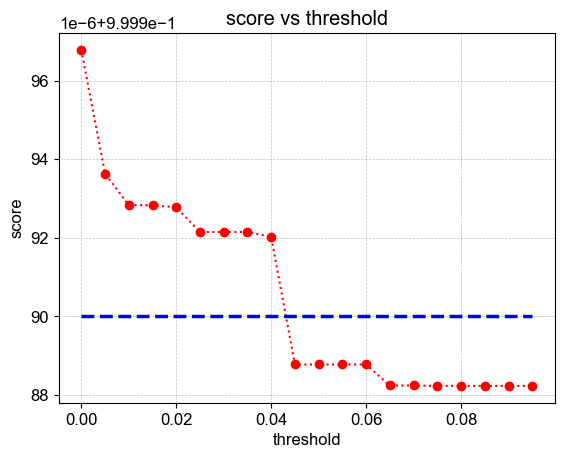

--------------------------------------------------
optimal_threshold: 0.04
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.079 r + -7.321 r_dot + -3.037 q + 0.311 r^2 + -91.531 r^2 r_dot + -1.170 r_dot^2 q + 1.256 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.842 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999920246835962
Iteration: 82
[-0.02452405  0.03906091 -0.01832733 -0.03191569]


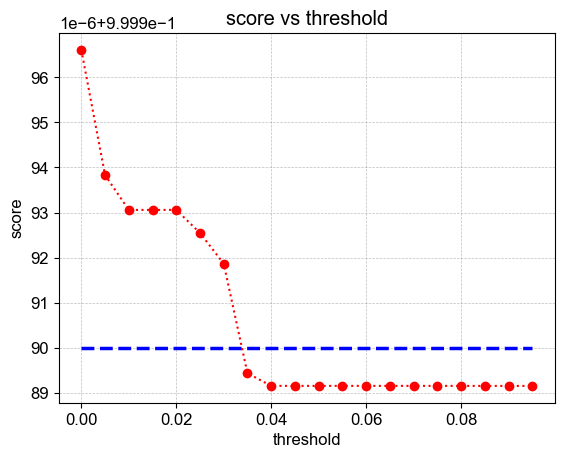

--------------------------------------------------
optimal_threshold: 0.03
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -337.972 r + -7.358 r_dot + -3.036 q + 0.143 r^2 + 0.087 r_dot^2 + -62.600 r^2 r_dot + 0.325 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.842 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.999991865849812
Iteration: 83
[ 0.04814108 -0.00758268 -0.00492503 -0.01503917]


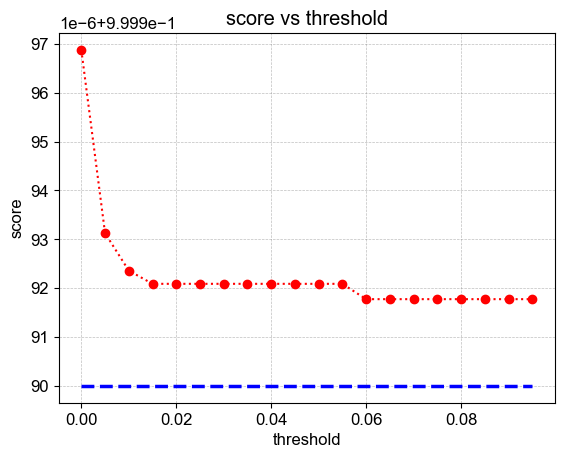

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.105 r + -7.336 r_dot + -3.037 q + -1.673 r^2 + -42.137 r^2 r_dot + 1.251 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + 0.082 r^2 + -0.287 q^2 q_dot
Score on training data:
0.9999917751188293
Iteration: 84
[ 0.04750607 -0.00406759  0.02607292  0.01835037]


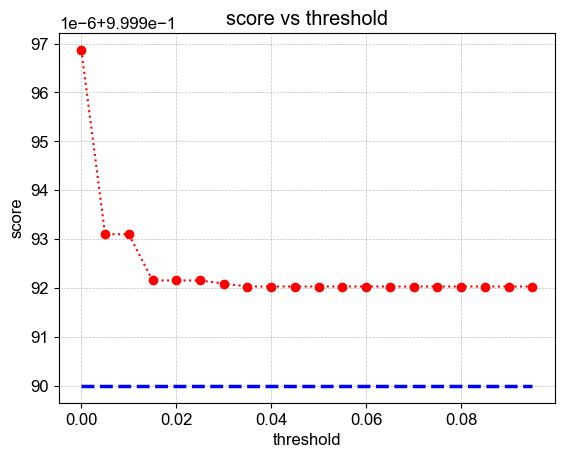

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.239 r + -7.312 r_dot + -3.038 q + -1.432 r^2 + -63.581 r^2 r_dot + -2.101 r_dot^2 q + 1.467 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + 0.073 r^2 + -0.287 q^2 q_dot
Score on training data:
0.9999920323041678
Iteration: 85
[-0.03593085 -0.00456274  0.03196473  0.04171778]


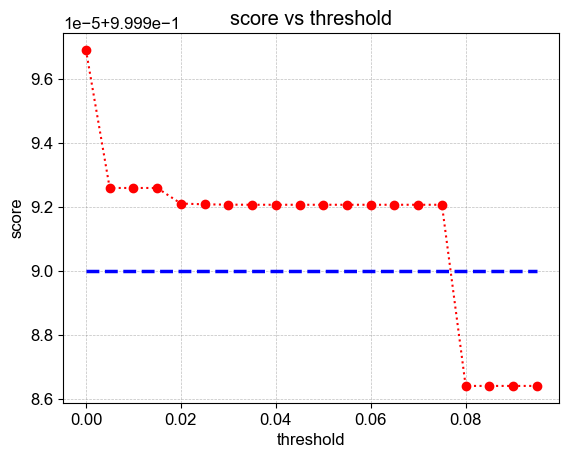

--------------------------------------------------
optimal_threshold: 0.075
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.288 r + -7.319 r_dot + -3.039 q + 0.633 r^2 + -129.827 r^2 r_dot + 1.375 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.844 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.999992064864707
Iteration: 86
[-0.00430408 -0.03200024 -0.03048702  0.02794397]


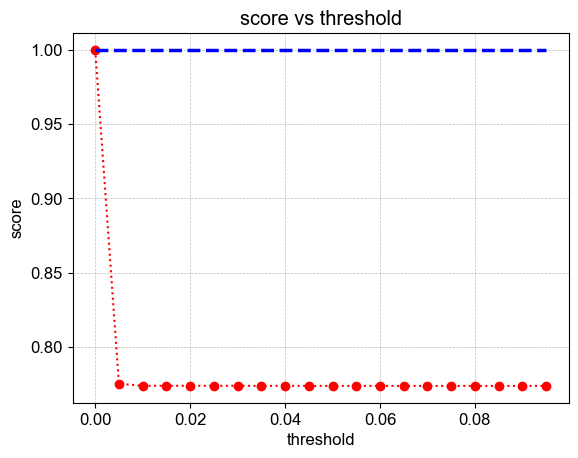

--------------------------------------------------
optimal_threshold: 0.0
--------------------------------------------------
Identified model:
(r)' = 0.034 r + 0.995 r_dot + 0.019 r^2 + 0.005 r_dot^2 + -87.186 r^2 r_dot + -0.020 r^2 q + -1.723 r^2 q_dot + -0.041 r_dot^2 q + 0.001 r_dot^2 q_dot
(r_dot)' = -338.096 r + -7.336 r_dot + -3.037 q + 1.987 r^2 + 0.480 r_dot^2 + -9237.189 r^2 r_dot + -2.081 r^2 q + -182.573 r^2 q_dot + -4.317 r_dot^2 q + 0.066 r_dot^2 q_dot + 0.008 q^2 q_dot
(q)' = -0.003 r + 0.001 r_dot + 1.000 q_dot + -0.003 r_dot^2 + -60.134 r^2 r_dot + 0.065 r^2 q + 0.178 r^2 q_dot + -0.091 r_dot^2 q
(q_dot)' = 22.859 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.009 r^2 + 0.055 r_dot^2 + 691.898 r^2 r_dot + 0.090 r^2 q + 86.827 r^2 q_dot + 3.550 r_dot^2 q + -0.160 r_dot^2 q_dot + -0.294 q^2 q_dot
Score on training data:
0.999995558107244
Iteration: 87
[ 0.01401136  0.03664925 -0.00042758 -0.02247615]


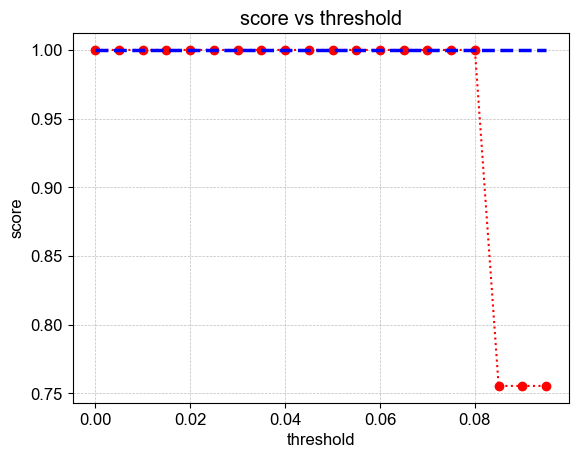

--------------------------------------------------
optimal_threshold: 0.08
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.945 r + -7.373 r_dot + -3.036 q + -0.172 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 20.250 r + -1.251 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999913022949757
Iteration: 88
[-0.00105548  0.03625748  0.01222102  0.01751653]


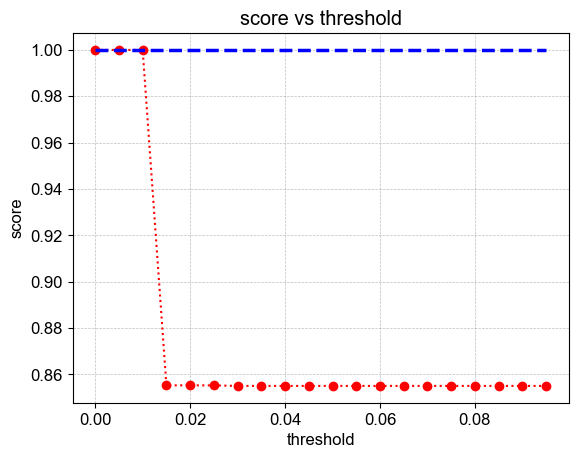

--------------------------------------------------
optimal_threshold: 0.01
--------------------------------------------------
Identified model:
(r)' = 1.000 r_dot
(r_dot)' = -337.241 r + -7.337 r_dot + -3.029 q + -0.007 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 22.792 r + 0.496 r_dot + -1.228 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999988786799582
Iteration: 89
[ 0.01174818 -0.01614934 -0.03166899 -0.01691147]


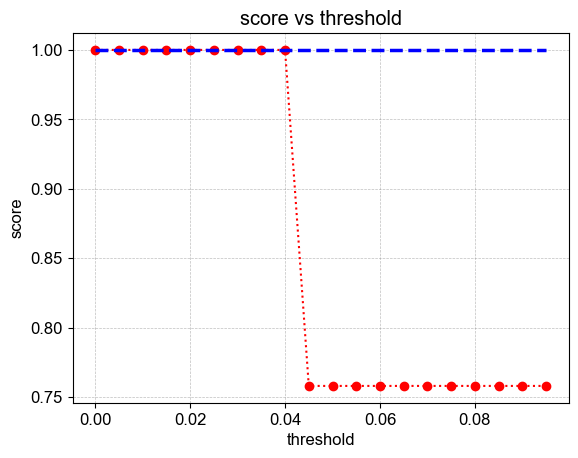

--------------------------------------------------
optimal_threshold: 0.04
--------------------------------------------------
Identified model:
(r)' = 0.999 r_dot
(r_dot)' = -337.887 r + -7.369 r_dot + -3.035 q
(q)' = 1.000 q_dot
(q_dot)' = 19.707 r + -1.256 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.999992478474991
Iteration: 90
[-0.03539526 -0.0115215  -0.01593053  0.01373096]


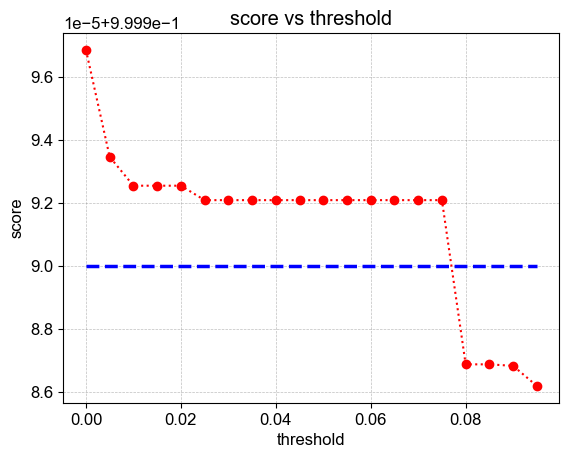

--------------------------------------------------
optimal_threshold: 0.075
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.308 r + -7.319 r_dot + -3.039 q + 0.647 r^2 + 0.028 r_dot^2 + -140.185 r^2 r_dot + -0.498 r_dot^2 q + 1.412 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999920861097544
Iteration: 91
[0.02737611 0.02044946 0.01635974 0.04996953]


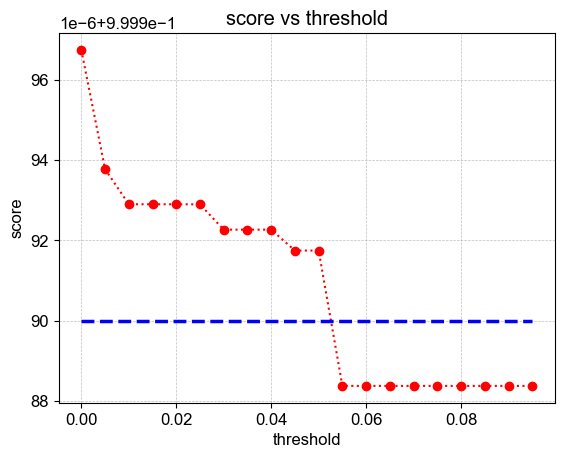

--------------------------------------------------
optimal_threshold: 0.05
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.186 r + -7.355 r_dot + -3.038 q + -0.242 r^2 + -0.099 r_dot^2 + -164.807 r^2 r_dot + 0.297 r_dot^2 q
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.999991746708889
Iteration: 92
[-0.01880396 -0.04536243  0.02672264  0.00217739]


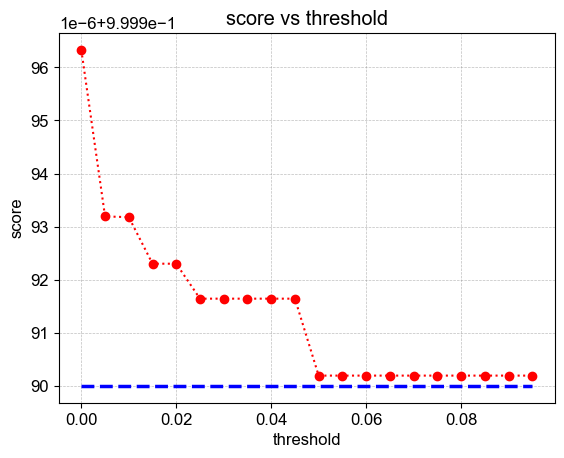

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.945 r + -7.371 r_dot + -3.036 q + 0.018 r^2 + 0.126 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 20.228 r + -1.251 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999901942850994
Iteration: 93
[ 0.02476279  0.0486443  -0.03087692 -0.01722443]


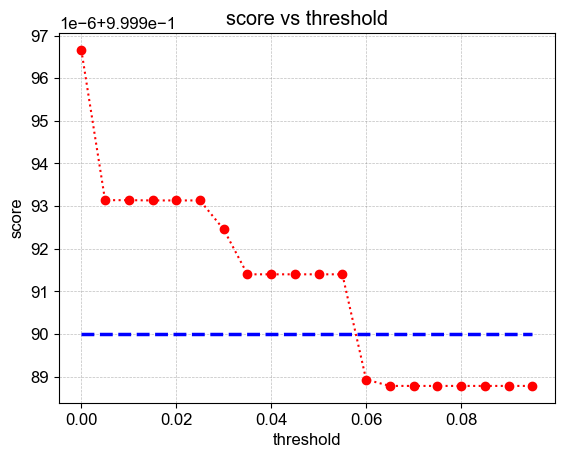

--------------------------------------------------
optimal_threshold: 0.055
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -337.947 r + -7.352 r_dot + -3.036 q + -0.139 r^2 + -0.050 r_dot^2 + 0.572 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999913995696348
Iteration: 94
[-0.03329823 -0.01385897  0.03523842  0.04672144]


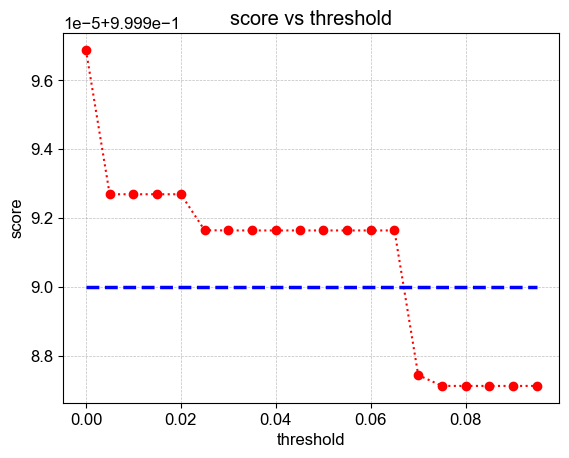

--------------------------------------------------
optimal_threshold: 0.065
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.203 r + -7.354 r_dot + -3.038 q + 0.468 r^2 + 0.078 r_dot^2 + -116.101 r^2 r_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.845 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999916391224682
Iteration: 95
[-0.0275481   0.03659272 -0.04533619 -0.03251955]


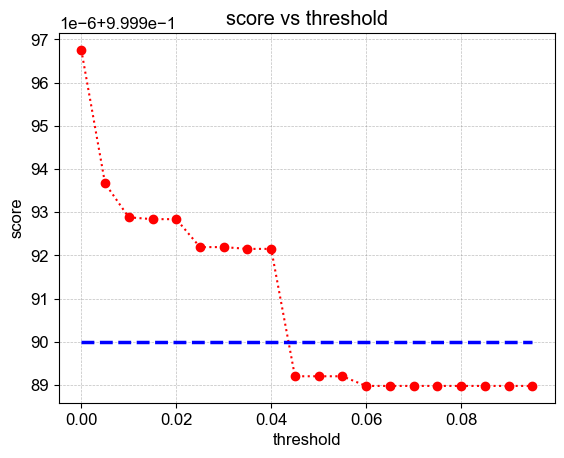

--------------------------------------------------
optimal_threshold: 0.04
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.126 r + -7.321 r_dot + -3.037 q + 0.270 r^2 + -124.311 r^2 r_dot + -0.947 r_dot^2 q + 1.285 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.842 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999921508718965
Iteration: 96
[-0.00658786 -0.04253099  0.02419495  0.01788955]


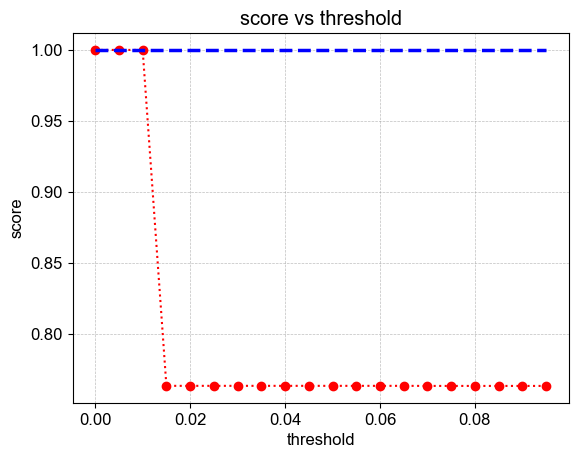

--------------------------------------------------
optimal_threshold: 0.01
--------------------------------------------------
Identified model:
(r)' = 1.000 r_dot
(r_dot)' = -337.929 r + -7.376 r_dot + -3.035 q + -0.121 r^2 + 0.258 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 22.846 r + 0.497 r_dot + -1.227 q + 0.287 q_dot + -0.010 r_dot^2 + -0.287 q^2 q_dot
Score on training data:
0.9999931303214709
Iteration: 97
[-0.02925865  0.01833108  0.04008147 -0.02299883]


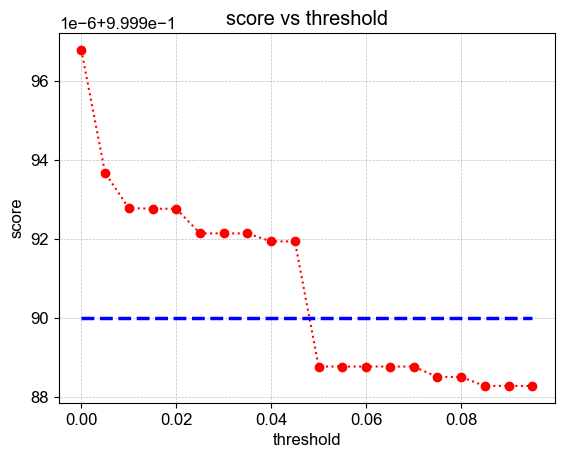

--------------------------------------------------
optimal_threshold: 0.045
--------------------------------------------------
Identified model:
(r)' = 0.997 r_dot
(r_dot)' = -338.138 r + -7.323 r_dot + -3.037 q + 0.340 r^2 + -118.907 r^2 r_dot + 0.812 r_dot^2 q + 1.007 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.843 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999919314975103
Iteration: 98
[ 0.04870803 -0.01777933 -0.04897638 -0.01827028]


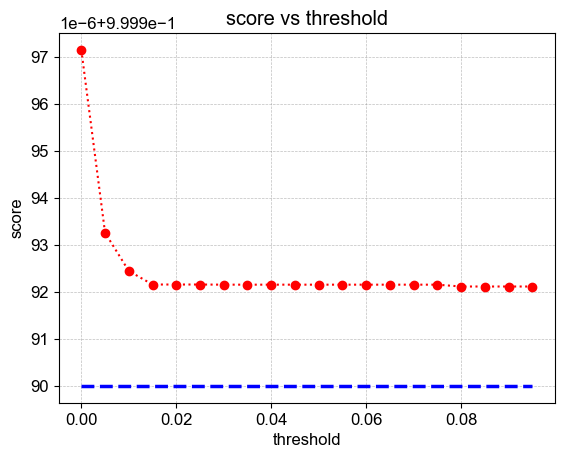

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.996 r_dot
(r_dot)' = -338.234 r + -7.314 r_dot + -3.038 q + -1.446 r^2 + -65.178 r^2 r_dot + 0.712 r_dot^2 q + 1.440 r_dot^2 q_dot
(q)' = 1.000 q_dot
(q_dot)' = 22.842 r + 0.496 r_dot + -1.227 q + 0.287 q_dot + 0.072 r^2 + -0.287 q^2 q_dot
Score on training data:
0.9999921171499706
Iteration: 99
[0.01802527 0.03752897 0.01991848 0.03588852]


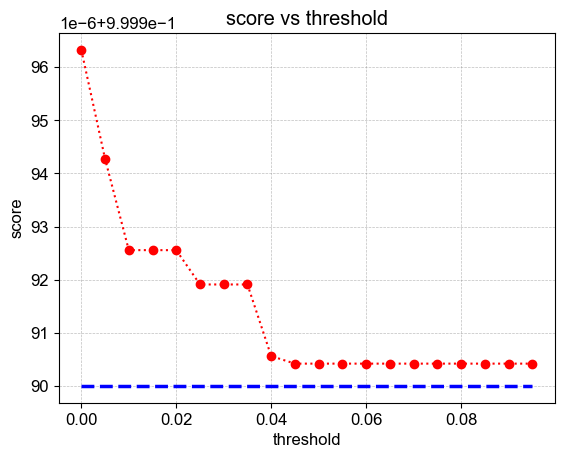

--------------------------------------------------
optimal_threshold: 0.095
--------------------------------------------------
Identified model:
(r)' = 0.998 r_dot
(r_dot)' = -337.943 r + -7.371 r_dot + -3.036 q + -0.005 r^2 + -0.127 r_dot^2
(q)' = 1.000 q_dot
(q_dot)' = 20.178 r + -1.251 q + 0.283 q_dot + -0.287 q^2 q_dot
Score on training data:
0.9999904196957567


In [6]:
n_initial_conditions = 100

for iter in range(n_initial_conditions):

    print(f'Iteration: {iter}')

     # generate the data for testing
    start = 0
    end = 100
    step = 0.01
    n_points = int((end-start)/step)
    t_span = [start, end]

    # generate random initial condition between -2 and 2
    x0 = np.random.rand(4) * 0.1 - 0.05
    print(x0)

    sol = solve_ivp(coupled_vdp_ac, t_span, x0, rtol=1e-10, atol=1e-10, dense_output=True)
    t = np.arange(start, end+step/10, step)
    x = sol.sol(t).T

    # The feature names of the columns of y
    feature_names = ['r', 'r_dot', 'q', 'q_dot']

    functions = [lambda x : x,
                lambda x: x ** 2,
                lambda x,y: x ** 2 * y
                ]

    function_names = [lambda x : str(x), 
                    lambda x: str(x) + "^2",
                    lambda x,y: str(x) + "^2 " + str(y)
                    ]


    lib_custom = CustomLibrary(library_functions=functions, 
                            function_names=function_names)
    lib_custom.fit(x)
    lib_custom.transform(x)

    feature_library = lib_custom


    feature_library.fit(x)

    # Differentiation method
    differentiation_method = ps.FiniteDifference(order=2)

    scores = []

    threshold_start = 0
    threshold_end = 0.1
    threshold_step = 0.005

    thresholds = np.arange(threshold_start, threshold_end, threshold_step)

    for threshold in thresholds:
        opt = ps.STLSQ(threshold=threshold)
        model=ps.SINDy(differentiation_method=differentiation_method,
                    feature_library = feature_library,
                    feature_names=feature_names, 
                    optimizer=opt)
        model.fit(x,t=t)
        scores.append(model.score(x,t=t))

    score_threshold = 0.99999
    threshold_line = np.ones(thresholds.shape) * score_threshold

    plt.plot(thresholds, scores, 'ro:')
    plt.plot(thresholds, threshold_line, 'b--', linewidth=2.5)
    plt.xlabel('threshold')
    plt.ylabel('score')
    plt.yscale('linear')
    plt.title('score vs threshold')
    plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
    plt.show()



    optimal_threshold = None
    for i in range(len(scores)):
        if scores[i] > score_threshold:
            optimal_threshold = thresholds[i]
        else:
            break

    print('-'*50)
    print(f'optimal_threshold: {optimal_threshold}')
    print('-'*50)


    # optimal_threshold = 0.015 # for testing

    if optimal_threshold is None:
        raise ValueError('No threshold found that gives a score > score_threshold')
    else:
        opt = ps.STLSQ(
            threshold=optimal_threshold
            )
        model=ps.SINDy(differentiation_method=differentiation_method,
                        feature_library=feature_library,
                        feature_names=feature_names,
                        optimizer=opt)
        model.fit(x,t=t)
        print('Identified model:')
        model.print()

        print('Score on training data:')
        print(model.score(x,t=t))

    coefficients = model.coefficients()

    if iter == 0:
        z = np.array(coefficients)
    else:    
        z = np.vstack((z, coefficients))

In [7]:
z = z.reshape(n_initial_conditions,4,14)
z[5,:,:]

array([[ 0.00000000e+00,  9.95798995e-01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [-3.38134829e+02, -7.33760467e+00, -3.03743558e+00,
         0.00000000e+00,  1.34005807e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -5.16453239e+01,
         0.00000000e+00,  0.00000000e+00,  1.34132804e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         9.99974946e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 2.28445413e+01,  4.95999964e-01, -1.22708765e+00,
         2.87141527e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.

In [8]:
# getting the feature names
for idx, name in enumerate(model.get_feature_names()):
    print(f"{idx+1} : {name}")


# find the mean of the coefficients
mean = z.mean(axis=0)
# find the standard deviation of the coefficients
std = z.std(axis=0)
# create the zeroing criteria. If the standard deviation is greater than the mean, then zero out the coefficient
coeff_var = np.abs(std)/np.abs(mean)

# zero out the terms with a large standard deviation
mean[coeff_var>1] = 0

#print the mean and standard deviation

print("mean: ")
print(mean)

print("std: ")
print(std)

print('coeff_var: ')
print(coeff_var)


1 : r
2 : r_dot
3 : q
4 : q_dot
5 : r^2
6 : r_dot^2
7 : q^2
8 : q_dot^2
9 : r^2 r_dot
10 : r^2 q
11 : r^2 q_dot
12 : r_dot^2 q
13 : r_dot^2 q_dot
14 : q^2 q_dot
mean: 
[[ 0.00000000e+00  9.97144373e-01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-3.38008340e+02 -7.34423339e+00 -3.03616248e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  9.99975508e-01
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 2.21474637e+01  3.81968228e-01 -1.23340360e+00  2.86265768e-01
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 

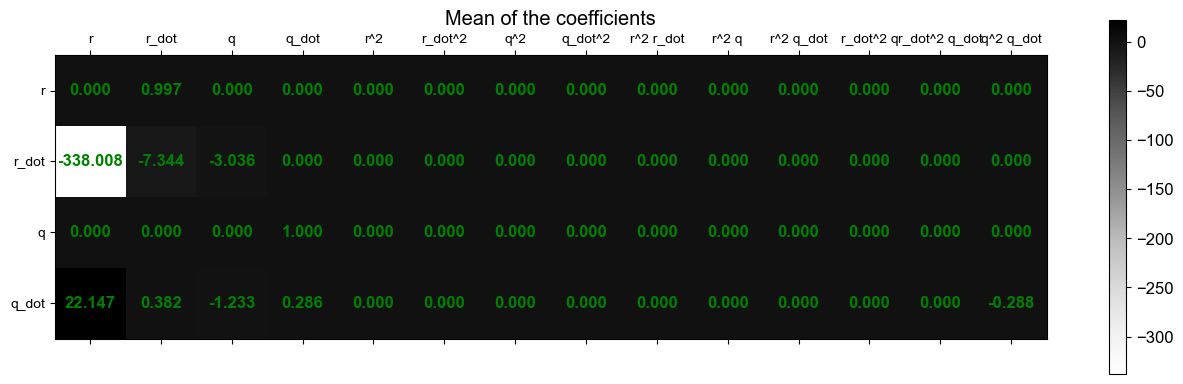

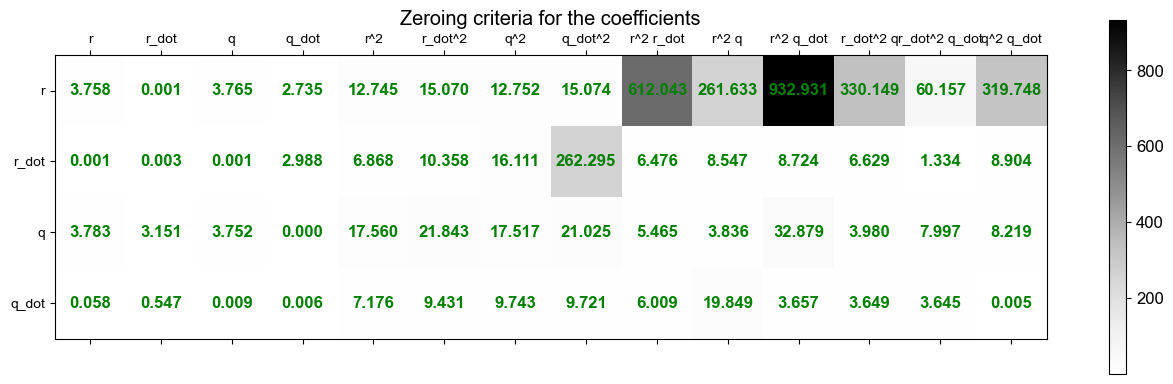

In [9]:
directory = case + '_coupling_custom'

if not os.path.exists(directory):
    os.makedirs(directory)

xticklabels = model.get_feature_names()
yticklabels = feature_names


plt.matshow(mean, cmap='Greys')
for i in range(mean.shape[0]):
    for j in range(mean.shape[1]):
        plt.annotate("{:.3f}".format(mean[i, j]), xy=(j, i), ha='center', va='center', color='green', fontsize=12, fontweight='bold')
plt.xticks(ticks=range(mean.shape[1]),labels=xticklabels, fontsize=10)
plt.yticks(ticks=range(mean.shape[0]),labels=yticklabels, fontsize=10)
plt.title("Mean of the coefficients")
plt.savefig(directory + '/' + "mean.pdf", dpi=300)
plt.colorbar()
plt.show()


plt.matshow(coeff_var, cmap='Greys')
for i in range(coeff_var.shape[0]):
    for j in range(coeff_var.shape[1]):
        plt.annotate("{:.3f}".format(coeff_var[i, j]), xy=(j, i), ha='center', va='center', color='green', fontsize=12, fontweight='bold')
plt.xticks(ticks=range(coeff_var.shape[1]),labels=xticklabels, fontsize=10)
plt.yticks(ticks=range(coeff_var.shape[0]),labels=yticklabels, fontsize=10)
plt.title("Coefficient of variation for the coefficients")
plt.savefig(directory + '/' + "coeff_var.pdf", dpi=300)
plt.colorbar()
plt.show()

In [10]:
# # Reduced Order Model
case='ROM_model'

Cd = 1.2
CL0 = 0.5
rho0 = 1.167e-6
D = 42
U0 = 0.1e3
L0 = 210
lbda = 0.24
A = 12
St = 0.08
zeta = 0.2
omega1 = 18.4097
phi_expr = -0.236617

def coupled_vdp_ac(t, x, args=(Cd, CL0, rho0, D, U0, L0, lbda, A, St, zeta, omega1, phi_expr)):
    # r = x[0]
    # rdot = x[1]
    # q = x[2]
    # qdot = x[3]
    omega_s = (2 * np.pi * St * U0) / D
    alpha = (( CL0 * rho0 * D * U0 ** 2 * L0)/4) * phi_expr

    xdot = np.zeros_like(x)
    xdot[0] = x[1] 
    xdot[1] = -2 * zeta * omega1 * x[1] - (( Cd * rho0 * D * U0 * L0) / 2) * (phi_expr) ** 2 * x[1] - omega1 ** 2 * x[0] + alpha * x[2]
    xdot[2] = x[3]
    xdot[3] = (A/D) * ((phi_expr) * (xdot[1])) - lbda * omega_s * (x[2] ** 2 - 1) * x[3]- omega_s ** 2 * x[2]

    return xdot

def id_sys(t, x):
    xdot = np.zeros_like(x)
    xdot[0] = 0.997 * x[1]
    xdot[1] = -338.049 * x[0] -7.343 * x[1] - 3.037 * x[2] 
    xdot[2] = x[3]
    xdot[3] = 22.199 * x[0] + 0.387 * x[1] - 1.233 * x[2] +0.286 * x[3] - 0.288 * (x[2]**2) * x[3]
    return xdot


# generate the data for testing
start = 0
end = 100
step = 0.01
t_span = [start, end]

# generate random initial condition between -2 and 2
x0 = np.random.rand(4) * 0.1 -  0.05
print(x0)

sol = solve_ivp(coupled_vdp_ac, t_span, x0, rtol=1e-10, atol=1e-10, dense_output=True)
t = np.arange(start, end+step/10, step)
x_true = sol.sol(t).T

sol = solve_ivp(id_sys, t_span, x0, rtol=1e-10, atol=1e-10, dense_output=True)
x_id = sol.sol(t).T  

# plt.plot(t,x_true[:,0])
# plt.plot(t,x_id[:,0])
# plt.show()

[-0.04050674  0.03712148  0.02935121  0.01503526]


In [11]:
directory = case + '_coupling_custom'

if not os.path.exists(directory):
    os.makedirs(directory)

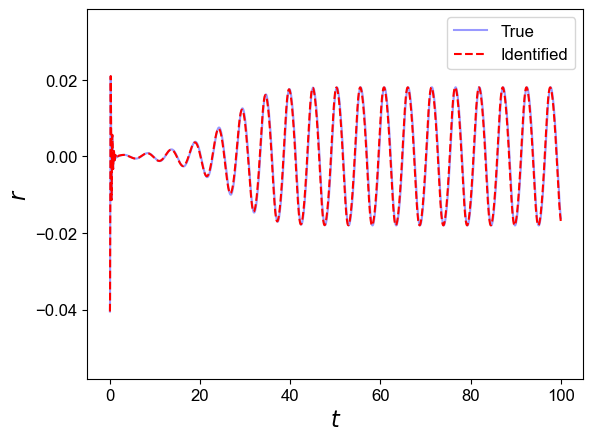

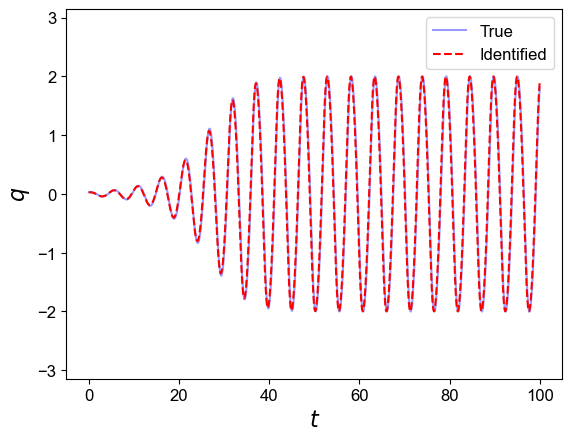

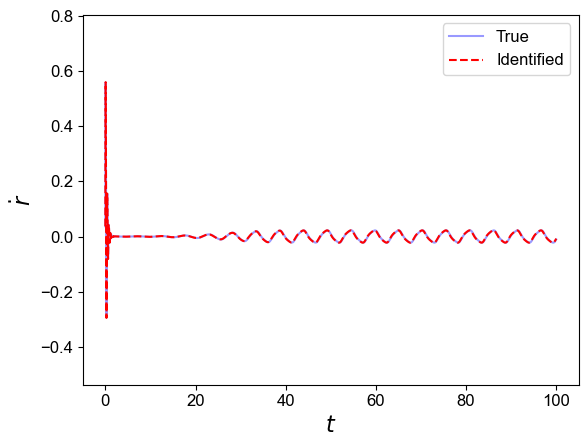

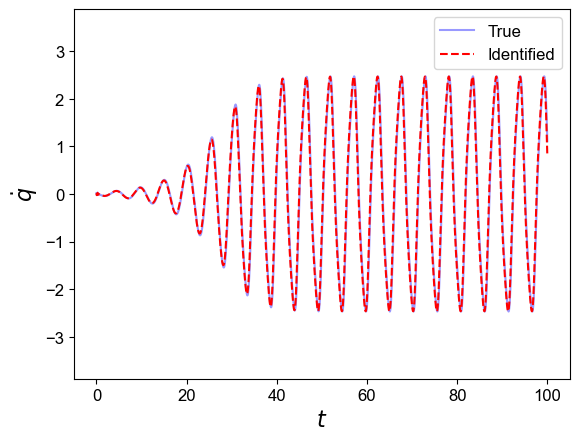

In [12]:
# plot the solution

plt.rcdefaults()
plt.rcParams.update({'font.size': 12})

plt.rcParams['font.family'] = 'Sans-Serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# x1
plot_comparison(t, x_true[:,0], x_id[:,0], "t", "r", "r", directory=directory)

# x2
plot_comparison(t, x_true[:,2], x_id[:,2], "t", "q", "q",directory=directory)

# x1 dot
plot_comparison(t, x_true[:,1], x_id[:,1], "t", "\dot{r}", "rdot", directory=directory)

# x2 dot
plot_comparison(t, x_true[:,3], x_id[:,3], "t", "\dot{q}", "qdot", directory=directory)

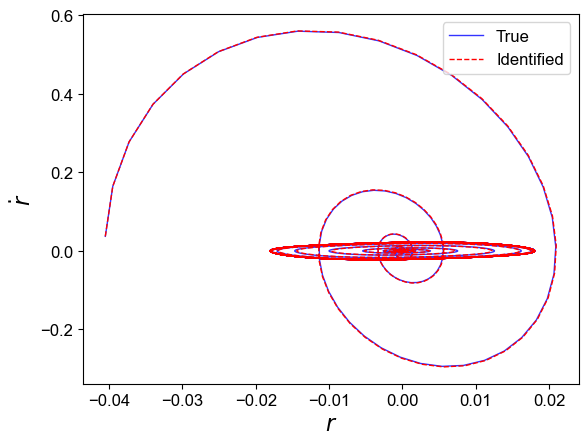

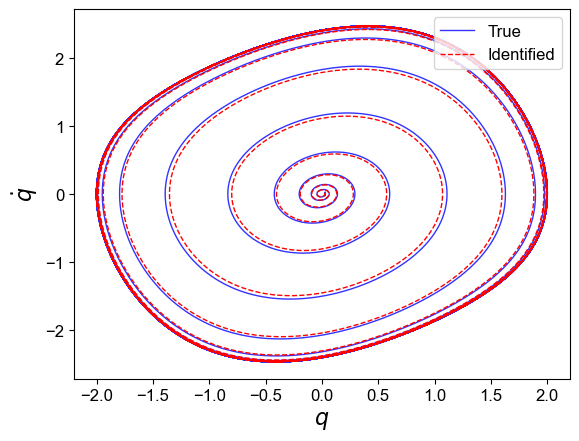

In [13]:
# Phase Portrait Oscillator 1
plot_pp(x_true[:,0], x_true[:,1], x_id[:,0], x_id[:,1], "r", "\dot{r}", "pp_r", directory=directory)

# Phase Portrait Oscillator 2
plot_pp(x_true[:,2], x_true[:,3], x_id[:,2], x_id[:,3], "q", "\dot{q}", "pp_q", directory=directory)

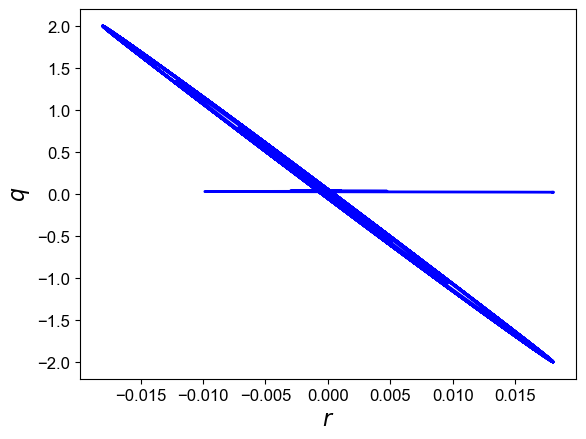

In [14]:
# Displacement Lissajous Figure
plot_lissajous(x[:,0], x[:,2], "r", "q", "lissajous_disp", directory=directory)

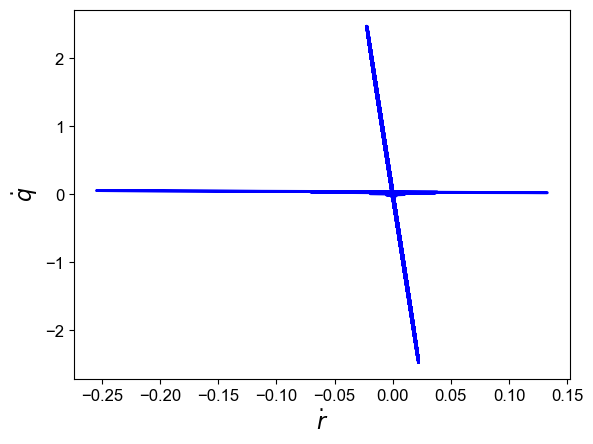

In [15]:
# Velocity Lissajous Figure
plot_lissajous(x[:,1], x[:,3], "\dot{r}", "\dot{q}", "lissajous_vel", directory=directory)